# Hydrographic Network In Steady State


In [2]:
# -*- coding: utf-8 -*-
"""
 * Copyright (c) 2023 Alexandre Gauvain, Ronan Abhervé, Jean-Raynald de Dreuzy
 *
 * This program and the accompanying materials are made available under the
 * terms of the Eclipse Public License 2.0 which is available at
 * http://www.eclipse.org/legal/epl-2.0, or the Apache License, Version 2.0
 * which is available at https://www.apache.org/licenses/LICENSE-2.0.
 *
 * SPDX-License-Identifier: EPL-2.0 OR Apache-2.0
"""



'\n * Copyright (c) 2023 Alexandre Gauvain, Ronan Abhervé, Jean-Raynald de Dreuzy\n *\n * This program and the accompanying materials are made available under the\n * terms of the Eclipse Public License 2.0 which is available at\n * http://www.eclipse.org/legal/epl-2.0, or the Apache License, Version 2.0\n * which is available at https://www.apache.org/licenses/LICENSE-2.0.\n *\n * SPDX-License-Identifier: EPL-2.0 OR Apache-2.0\n'

In [3]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import imageio
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = True

# ROOT DIRECTORY
from os.path import dirname, abspath
try:
    root_dir = '/home/bb/Documents/01_Git_Repository/01-HydroModPy-dev'
except NameError:
    root_dir = os.getcwd()
sys.path.append(root_dir)

# HYDROMODPY MODULES
from hydromodpy import watershed_root
from hydromodpy.display import visualization_watershed, visualization_results
from hydromodpy.tools import toolbox
fontprop = toolbox.plot_params(8,15,18,20)  # small, medium, interm, large



In [4]:

example_path = os.path.join(root_dir, "examples", "03_hydrographic_network_in_steady_state/")
data_path = os.path.join(example_path, "data/")

# The folder out_path is created in the example_path root directory:
out_path = os.path.join(root_dir,'examples', 'results')
# Or define it manually
#out_path = 'D:/_HydroModPy/_results/'

print('The results of the example will be saved here :', out_path)



The results of the example will be saved here : /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results


In [5]:

dem_path = os.path.join(data_path, 'regional dem.tif')
# dem_path = 'C:/Users/ronan/OneDrive/UNINE/12_Data/_GIS/dem/BDALTI_fr_75m.tif'
load = False
watershed_name = 'Example_03_Canut'
# watershed_name ='Strengbach'
from_lib = None # os.path.join(root_dir,'watershed_library.csv')
from_dem = None # [path, cell size]
from_shp = None # [path, buffer size]
from_xyv = [327816.965, 6777886.670, 150, 10 , 'EPSG:2154'] # [x, y, snap distance, buffer size, crs proj]
bottom_path = None # path
save_object = True



In [ ]:

print('##### '+watershed_name.upper()+' #####')

load = True
BV = watershed_root.Watershed(dem_path=dem_path,
                              out_path=out_path,
                              load=load,
                              watershed_name=watershed_name,
                              from_lib=from_lib, # os.path.join(root_dir,'watershed_library.csv')
                              from_dem=from_dem, # [path, cell size]
                              from_shp=from_shp, # [path, buffer size]
                              from_xyv=from_xyv, # [x, y, snap distance, buffer size]
                              bottom_path=bottom_path, # path
                              save_object=save_object)

# Paths generated automatically but necessary for plots
stable_folder = os.path.join(out_path, watershed_name, 'results_stable')
simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')



[INFO]       __  __          __           __  ____          ________     


[INFO]      / / / /         / /          /  \/   /         / / __  /     


[INFO]     / /_/ /_  ______/ /________  /       /___  ____/ / /_/ /_  __ 


[INFO]    / __  / / / / __  / ___/ __ \/ /\,-/ / __ \/ __  / ____/ / / / 


[INFO]   / / / / /_/ / /_/ / /  / /_/ / /   / / /_/ / /_/ / /   / /_/ /  


[INFO]  /_/ /_/\__, /_____/_/   \____/_/   /_/\____/_____/_/____\__, /   


[INFO]        /____/ Hydrological Modelling in Python /_____________/    


[INFO]                                                                   


[INFO] Python object was successfully loaded as requested; imported from output directory /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_03_Canut


##### EXAMPLE_03_CANUT #####


[INFO] Extracting geology data from /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/03_hydrographic_network_in_steady_state/data/


[INFO] Extracting hydrography data from /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/03_hydrographic_network_in_steady_state/data/


[INFO] Extracting hydrometry data from /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/03_hydrographic_network_in_steady_state/data/


[INFO] Extracting stream intermittency data from /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/03_hydrographic_network_in_steady_state/data/


[INFO] Extracting subbasin definitions for watershed


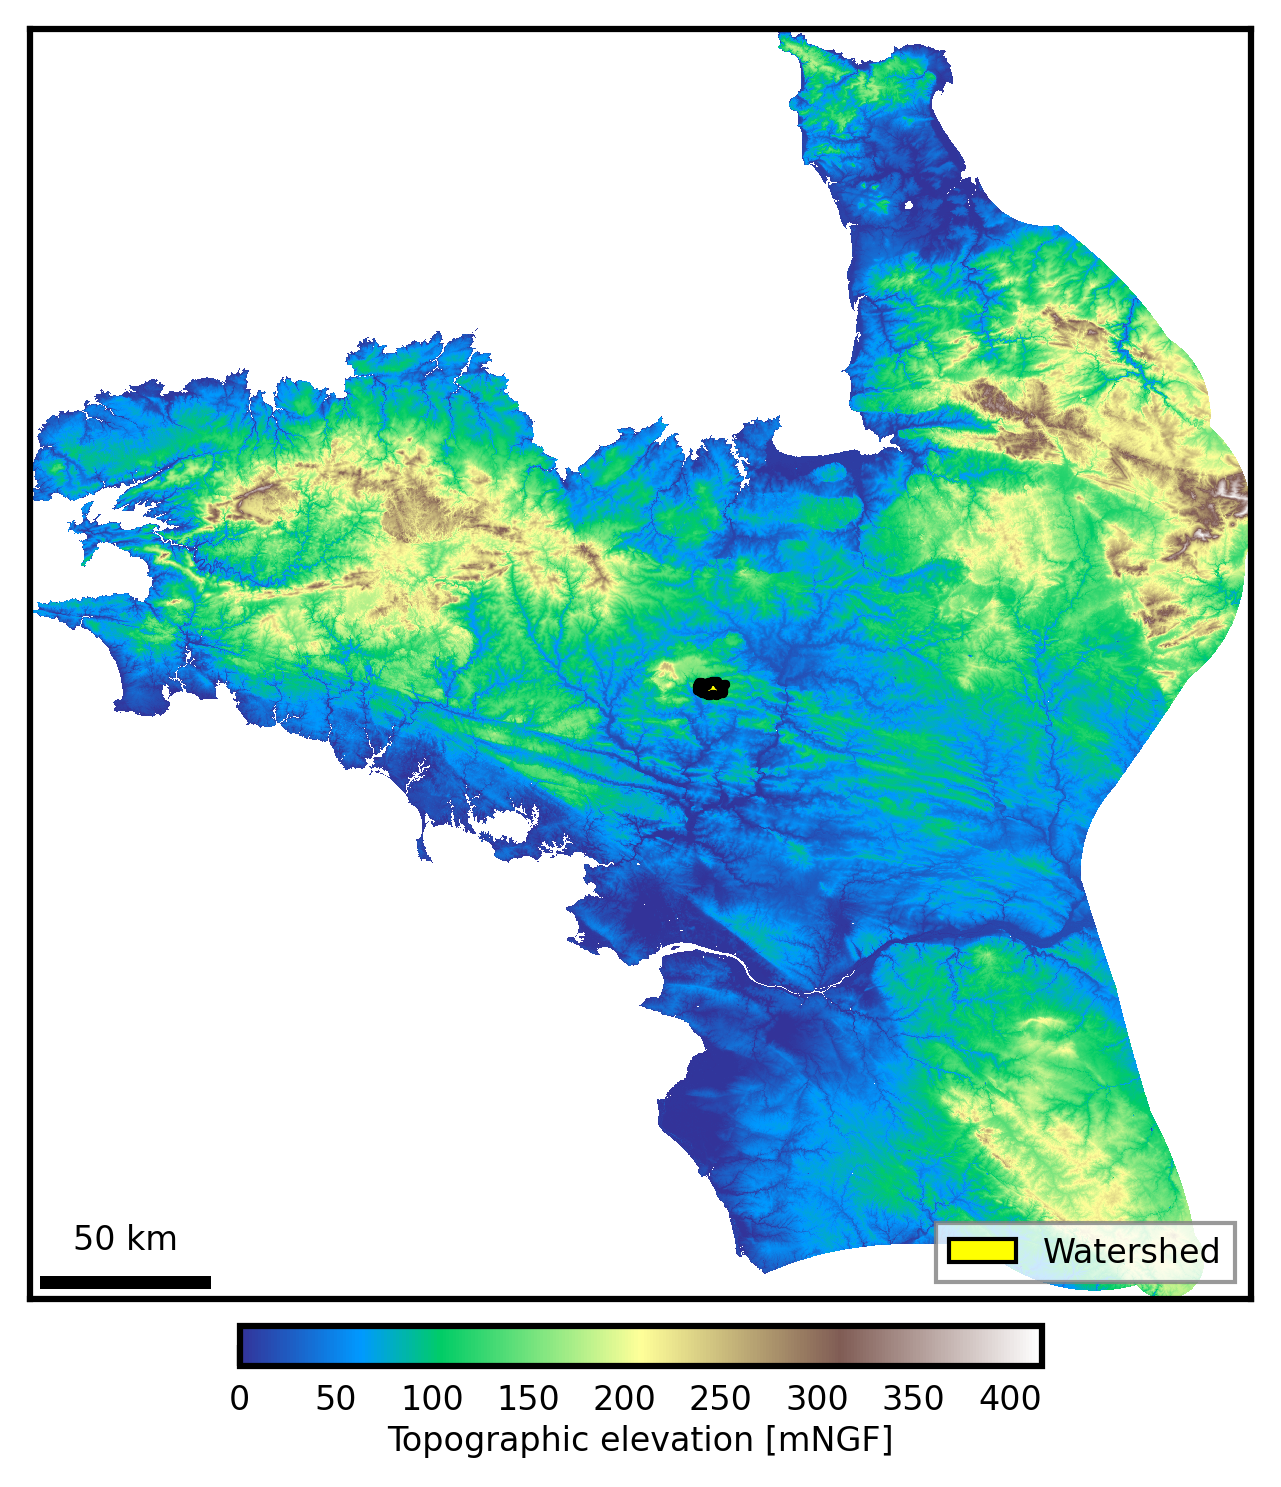

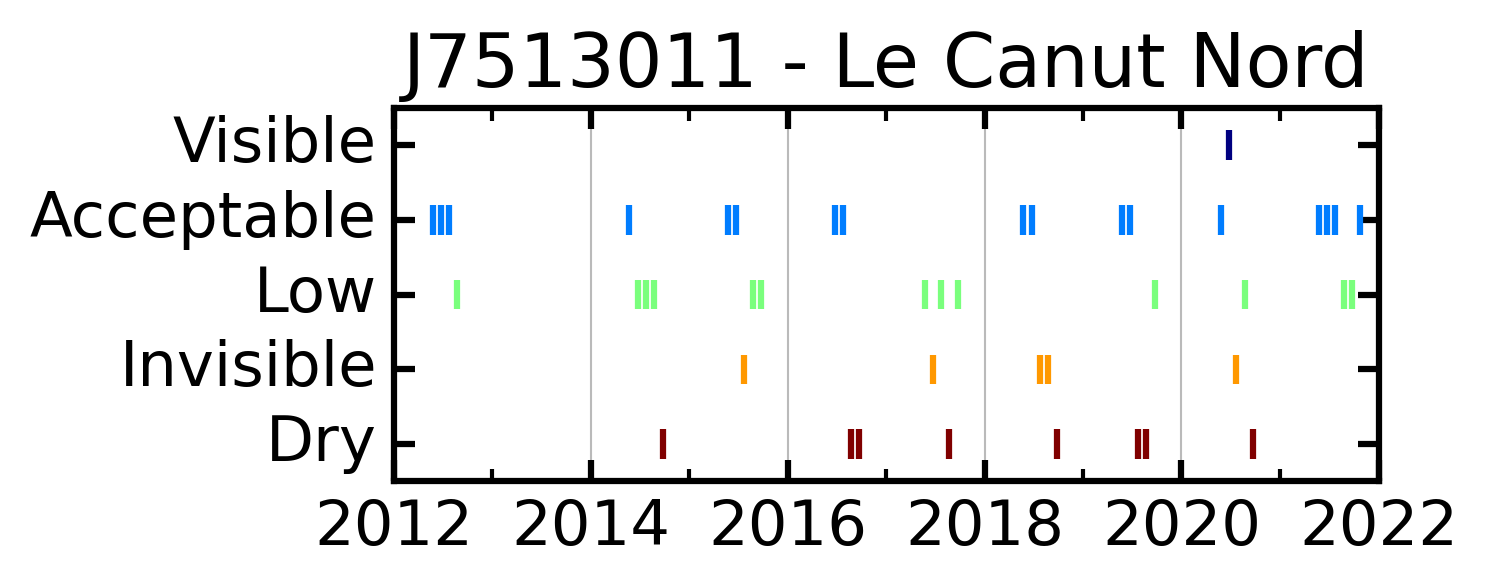

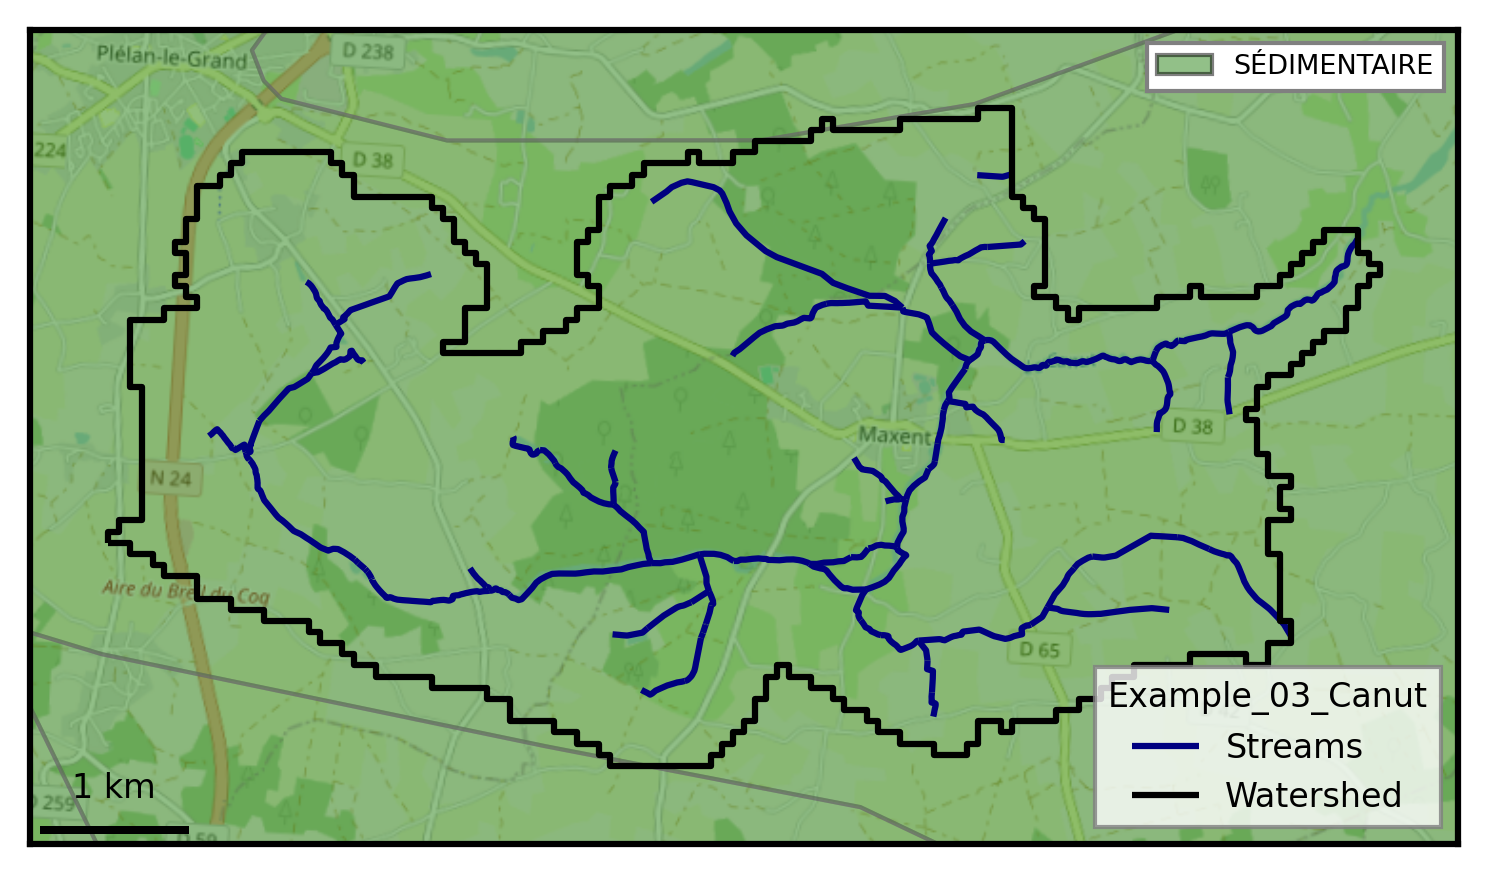

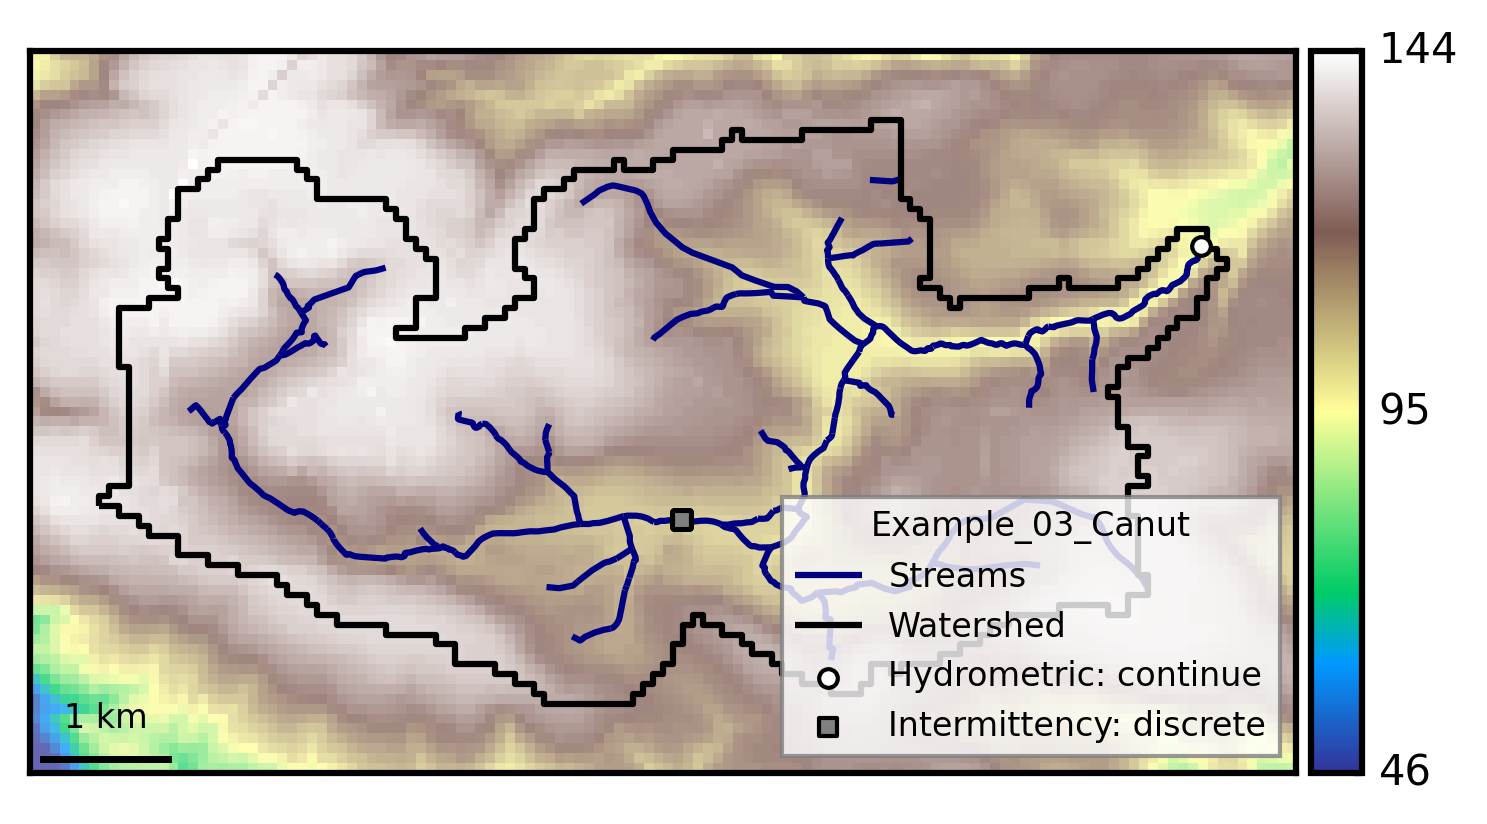

In [ ]:

visualization_watershed.watershed_local(dem_path, BV)

if from_dem == None:
    # Clip specific data at the catchment scale
    BV.add_geology(data_path, types_obs='GEO1M.shp', fields_obs='CODE_LEG')
    BV.add_hydrography(data_path, types_obs=['regional stream network'])
    BV.add_hydrometry(data_path, 'france hydrometric stations.shp')
    BV.add_intermittency(data_path, 'regional onde stations.shp')
    # BV.add_piezometry()

    # Extract some subbasin from data available above
    BV.add_subbasin(os.path.join(data_path, 'additional'), 150)

# General plot of the study site
if from_dem == None:
    visualization_watershed.watershed_geology(BV)

visualization_watershed.watershed_dem(BV)



[INFO] Initializing climatic module parameters


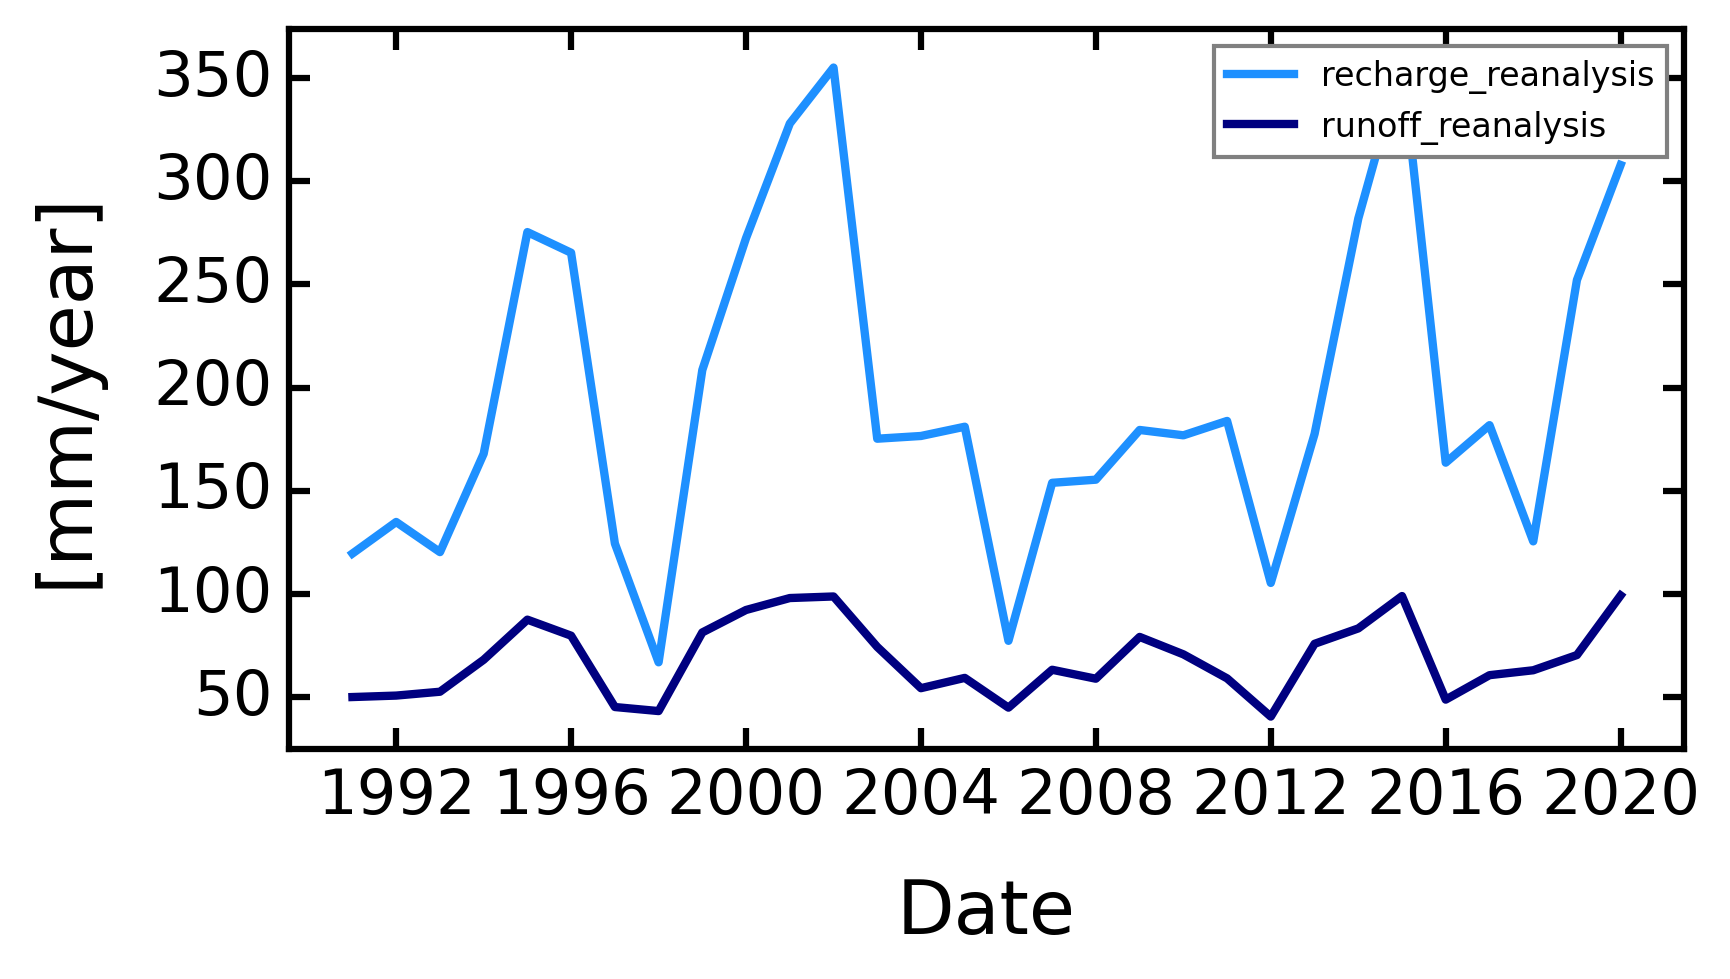

In [8]:

# # Necessary to set model parameters
BV.add_climatic()

BV.climatic.update_recharge_reanalysis(path_file=os.path.join(data_path,'_climate_REANALYSIS.csv'),
                                       clim_mod='REA',
                                       clim_sce='historic',
                                       first_year=1990,
                                       last_year=2019,
                                       time_step='D',
                                       sim_state='transient')
BV.climatic.update_runoff_reanalysis(path_file=os.path.join(data_path,'_climate_REANALYSIS.csv'),
                                     clim_mod='REA',
                                     clim_sce='historic',
                                     first_year=1990,
                                     last_year=2019,
                                     time_step='D',
                                     sim_state='transient')

fig, ax = plt.subplots(1,1, figsize=(6,3))
R = BV.climatic.recharge.resample('Y').sum()#*1000
r = BV.climatic.runoff.resample('Y').sum()#*1000
ax.plot(R, label='recharge_reanalysis', c='dodgerblue', lw=2)
ax.plot(r, label='runoff_reanalysis', c='navy', lw=2)
ax.set_xlabel('Date')
ax.set_ylabel('[mm/year]')
ax.legend()



In [9]:

# Frame settings
box = True # or False
sink_fill = False # or True
# sim_state = 'transient' # 'steady' or 'transient'
sim_state = 'steady' # 'steady' or 'transient'
plot_cross = False
check_grid = False
dis_perlen=False

# Climatic settings
recharge = pd.Series([10,20,30,40,50,60,60,50,40,30,20,10])/30/1000
first_clim = 'mean' # or 'first or value
freq_time = 'M'

# Hydraulic settings
nlay = 5
lay_decay = 1 # 1 for no decay
bottom = None # elevation in meters, None for constant auifer thickness, or 2D matrix
thick = 50 # if bottom is None, aquifer thickness
cond_drain = None # or value of conductance
sy = 10 / 100 # -

########## LOOP ##########
list_hyd_cond = np.geomspace(1e-8,1e-3,10) * 24 * 3600 # m/day

# Boundary settings
bc_left = None # or value
bc_right = None # or value
sea_level = 'None' # or value based on specific data : BV.oceanic.MSL

# Particle tracking settings
zone_partic = 'domain' # or watershed



In [10]:

# Import modules
BV.add_settings()
BV.add_climatic()
BV.add_hydraulic()

# Frame settings
BV.settings.update_box_model(box)
BV.settings.update_sink_fill(sink_fill)
BV.settings.update_simulation_state(sim_state)
BV.settings.update_check_model(plot_cross=plot_cross, check_grid=check_grid)

# Climatic settings
BV.climatic.update_recharge(recharge, sim_state=sim_state)
BV.climatic.update_first_clim(first_clim)

# Hydraulic settings
BV.hydraulic.update_nlay(nlay) # 1
BV.hydraulic.update_bottom(bottom) # None
BV.hydraulic.update_thick(thick) # 30 / intervient pas si bottom != None
BV.hydraulic.update_sy(sy)
BV.hydraulic.update_cond_drain(cond_drain)
BV.hydraulic.update_lay_decay(lay_decay)

# Boundary settings
BV.settings.update_bc_sides(bc_left, bc_right)
BV.add_oceanic(sea_level)
BV.settings.update_dis_perlen(dis_perlen=dis_perlen)

# Particle tracking settings
BV.settings.update_input_particles(zone_partic=BV.geographic.watershed_box_buff_dem) # or 'seepage_path'



[INFO] Initializing settings module for groundwater parameters


[INFO] Initializing climatic module parameters


[INFO] Initializing hydraulic module for parameter setup


In [ ]:

iD_set_simulations = 'explorK_test1'

list_model_name = []
list_success_modflow = []
list_model_modflow = []

for hyd_cond in list_hyd_cond:
    BV.hydraulic.update_hk(hyd_cond)

    model_name = iD_set_simulations+'_'+str(round(hyd_cond,3))
    BV.settings.update_model_name(model_name)
    print(model_name)

    model_modflow = BV.preprocessing_modflow(for_calib=False)
    success_modflow = BV.processing_modflow(model_modflow, write_model=True, run_model=True)

    list_model_name.append(model_name)
    list_success_modflow.append(success_modflow)
    list_model_modflow.append(model_modflow)

dictio = {}
dictio['list_model_name'] = list_model_name
dictio['list_success_modflow'] = list_success_modflow
dictio['list_model_modflow'] = list_model_modflow
pickle_file = os.path.join(simulations_folder,'results_listing_'+iD_set_simulations+'.pkl')

with open(pickle_file, 'wb') as f:
    pickle.dump(dictio, f)



explorK_test1_0.001
FloPy is using the following executable to run the model: ../../../../../bin/linux/mfnwt

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: explorK_test1_0.001.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:47:25



 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.


 Run end date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:47:26
 Elapsed run time:  0.408 Seconds

  Normal termination of simulation
explorK_test1_0.003
FloPy is using the following executable to run the model: ../../../../../bin/linux/mfnwt

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: explorK_test1_0.003.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:47:26



 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.


 Run end date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:47:26
 Elapsed run time:  0.444 Seconds

  Normal termination of simulation
explorK_test1_0.011
FloPy is using the following executable to run the model: ../../../../../bin/linux/mfnwt

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: explorK_test1_0.011.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:47:26



...

 Run end date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:47:32
 Elapsed run time:  1.514 Seconds

  Normal termination of simulation
explorK_test1_24.041
FloPy is using the following executable to run the model: ../../../../../bin/linux/mfnwt

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: explorK_test1_24.041.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:47:33



 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.


 Run end date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:47:35
 Elapsed run time:  1.988 Seconds

  Normal termination of simulation
explorK_test1_86.4
FloPy is using the following executable to run the model: ../../../../../bin/linux/mfnwt

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: explorK_test1_86.4.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:47:35



 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.


 Run end date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:47:38
 Elapsed run time:  3.622 Seconds

  Normal termination of simulation


In [12]:

pickle_file = os.path.join(simulations_folder,'results_listing_'+iD_set_simulations+'.pkl')
with open(pickle_file, 'rb') as f:
    d = pickle.load(f)
list_model_name = d['list_model_name'][:]
list_success_modflow = d['list_success_modflow'][:]
list_model_modflow = d['list_model_modflow'][:]



In [ ]:

for model_name, success_modflow, model_modflow in zip(list_model_name,
                                                      list_success_modflow,
                                                      list_model_modflow):
    if success_modflow == True:
        BV.postprocessing_modflow(model_modflow,
                                  watertable_elevation = True,
                                  watertable_depth= True,
                                  seepage_areas = True,
                                  outflow_drain = True,
                                  groundwater_flux = True,
                                  groundwater_storage = True,
                                  accumulation_flux = True,
                                  persistency_index=False,
                                  intermittency_monthly=False,
                                  intermittency_daily=False,
                                  export_all_tif = False)

        timeseries_results = BV.postprocessing_timeseries(model_modflow=model_modflow,
                                                          model_modpath=None,
                                                          datetime_format=False,
                                                          subbasin_results=True) # or None

        netcdf_results = BV.postprocessing_netcdf(model_modflow,
                                                  datetime_format=False)



[INFO] Post-processing stress period 1/1


[INFO] Exporting watertable elevation time series


[INFO] Exporting watertable depth time series


[INFO] Exporting seepage areas time series


[INFO] Exporting outflow drain time series


...

[INFO] Exported catchment time series to /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_03_Canut/results_simulations/explorK_test1_86.4/_postprocess/_timeseries


[INFO] Exported time series for subbasin 1 to /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_03_Canut/results_simulations/explorK_test1_86.4/_subbasins/hydrometry_J7513010


[INFO] Exported time series for subbasin 2 to /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_03_Canut/results_simulations/explorK_test1_86.4/_subbasins/intermittency_J7513011


[INFO] Exported time series for subbasin 3 to /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_03_Canut/results_simulations/explorK_test1_86.4/_subbasins/subbasin_upstreamA


[INFO] Exporting MODFLOW results as NetCDF for model explorK_test1_86.4


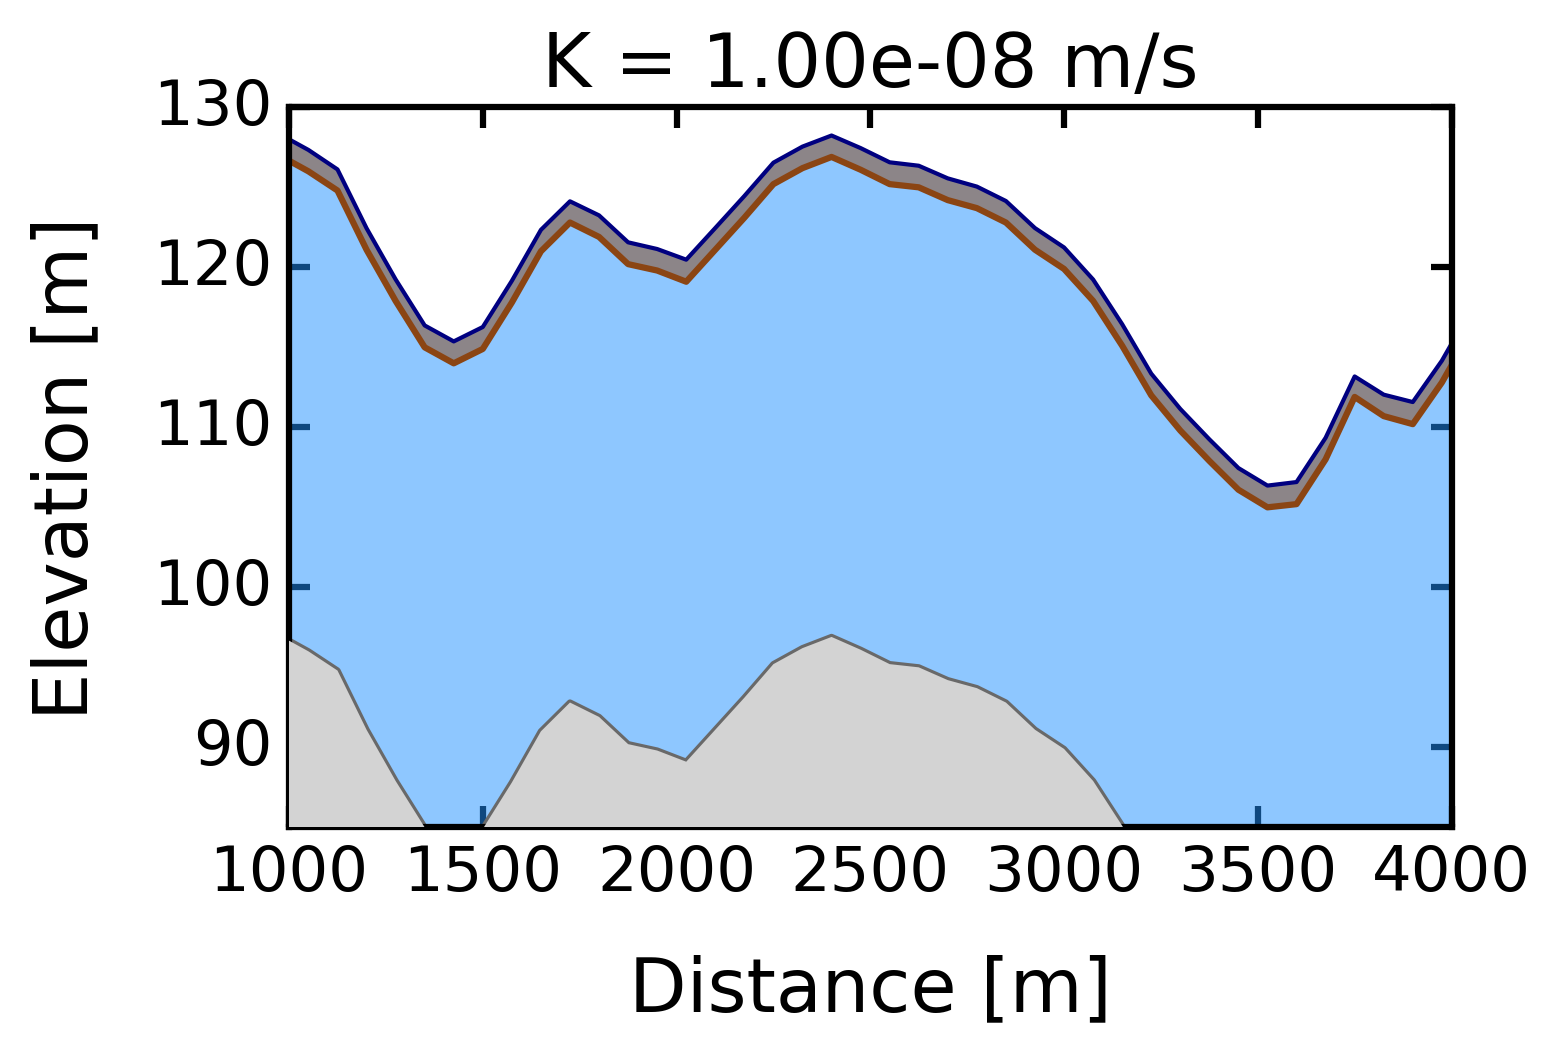

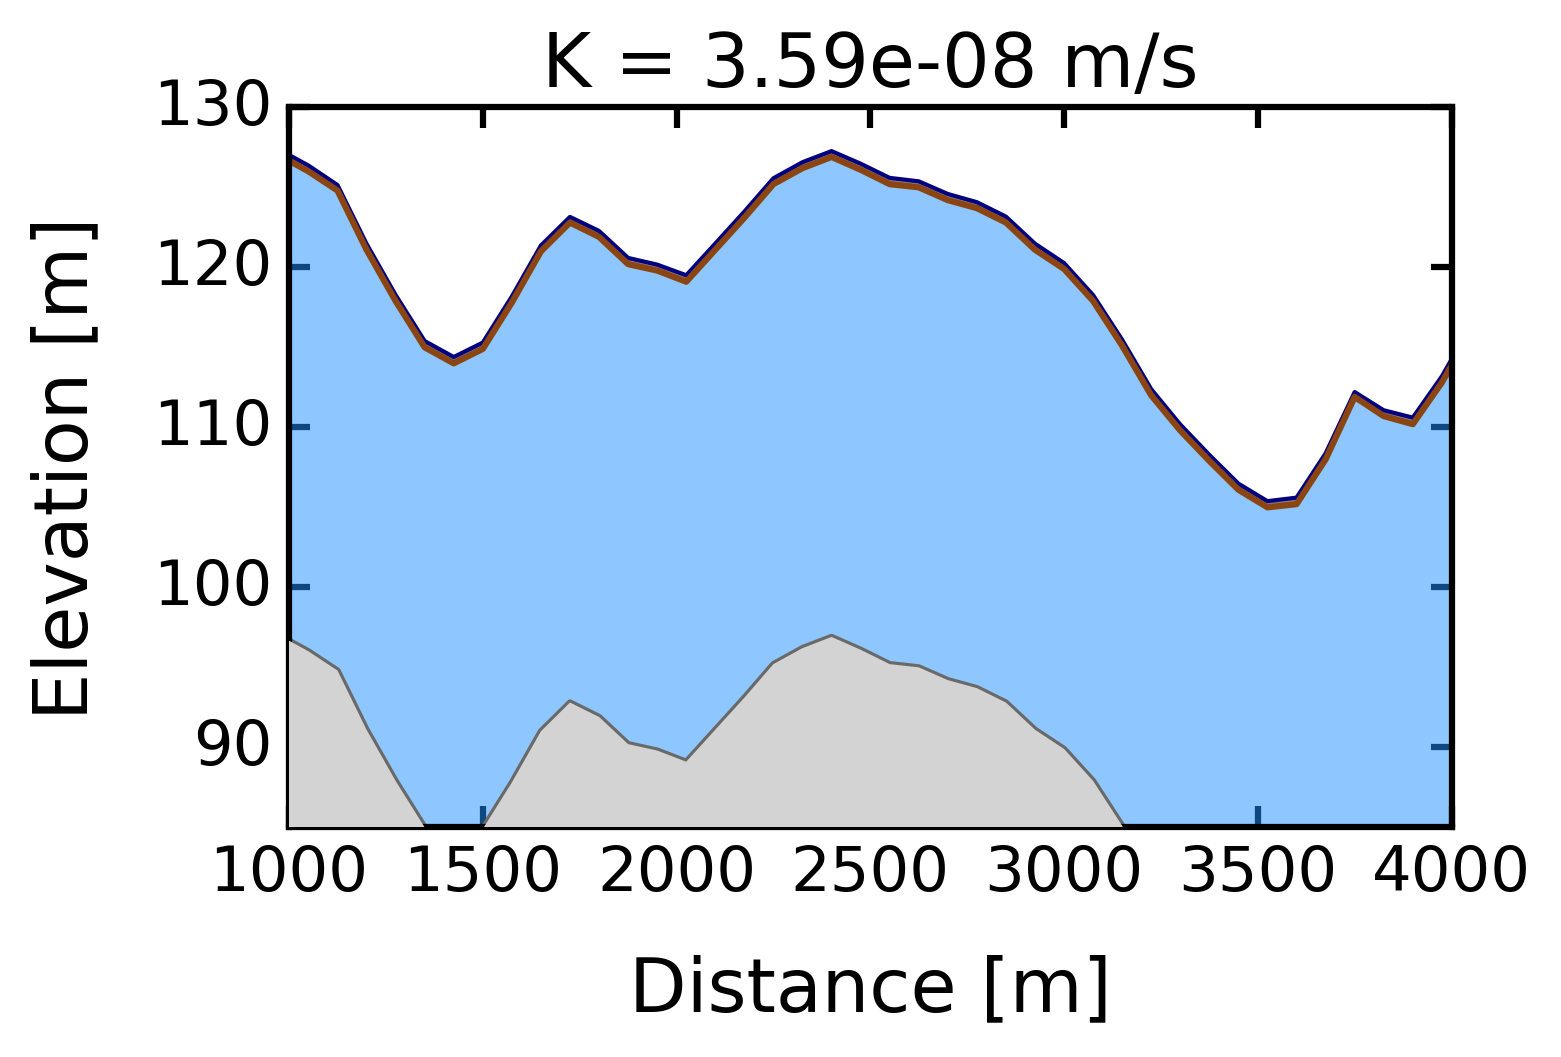

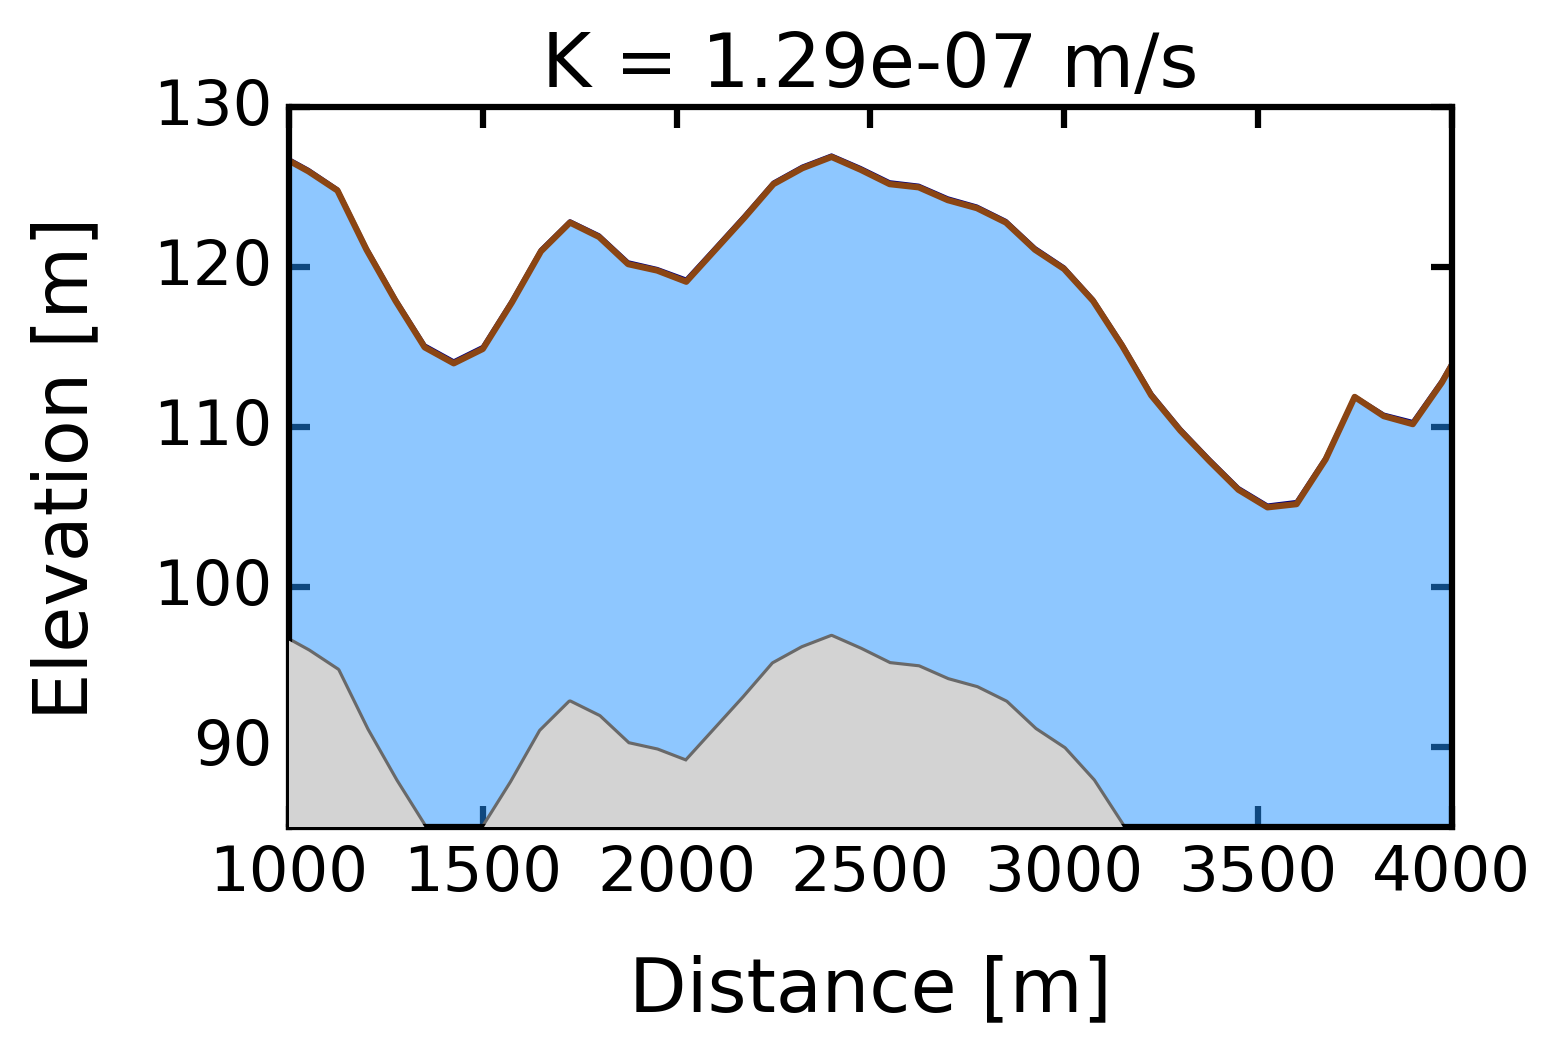

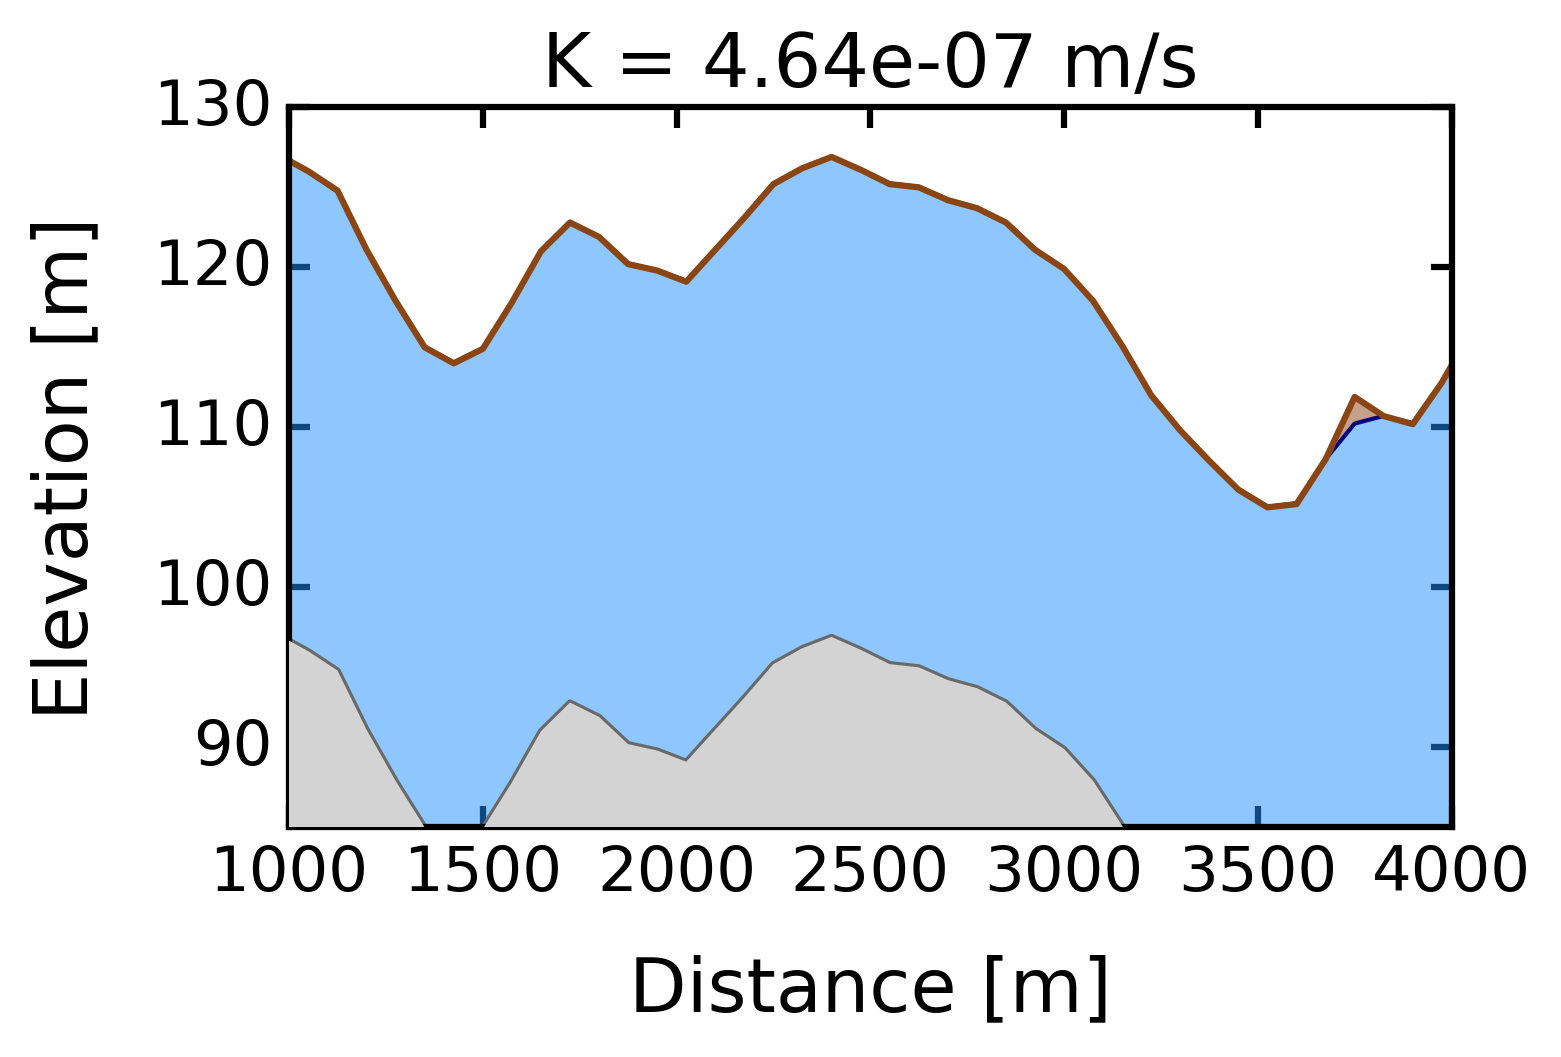

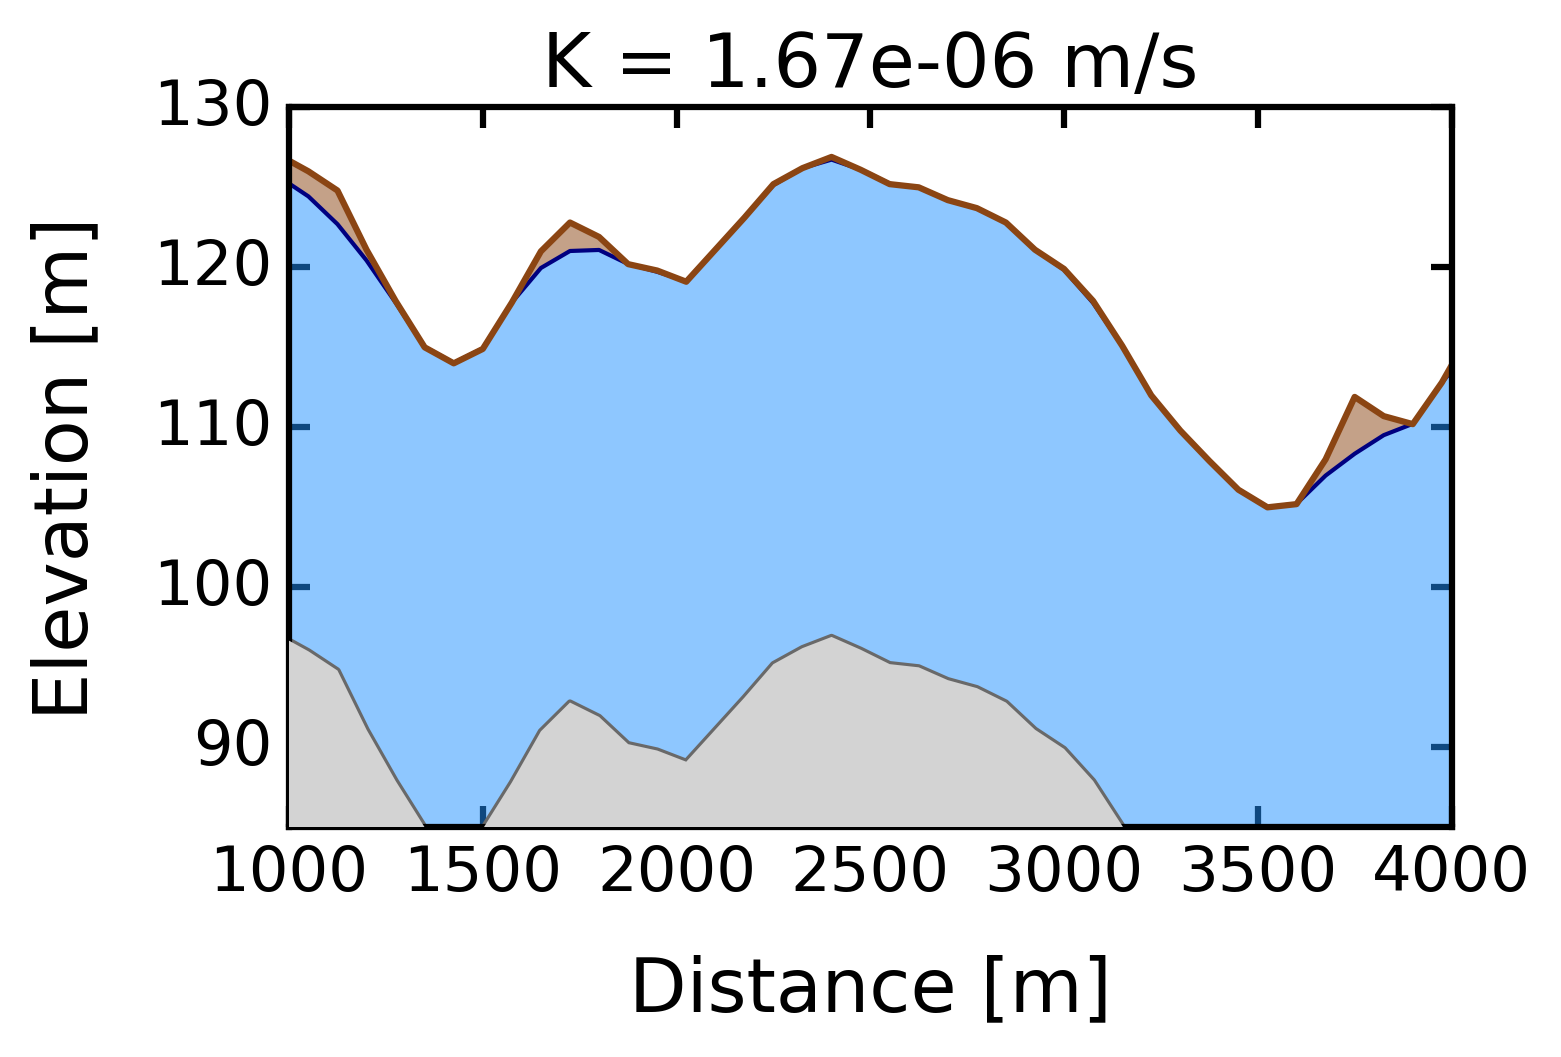

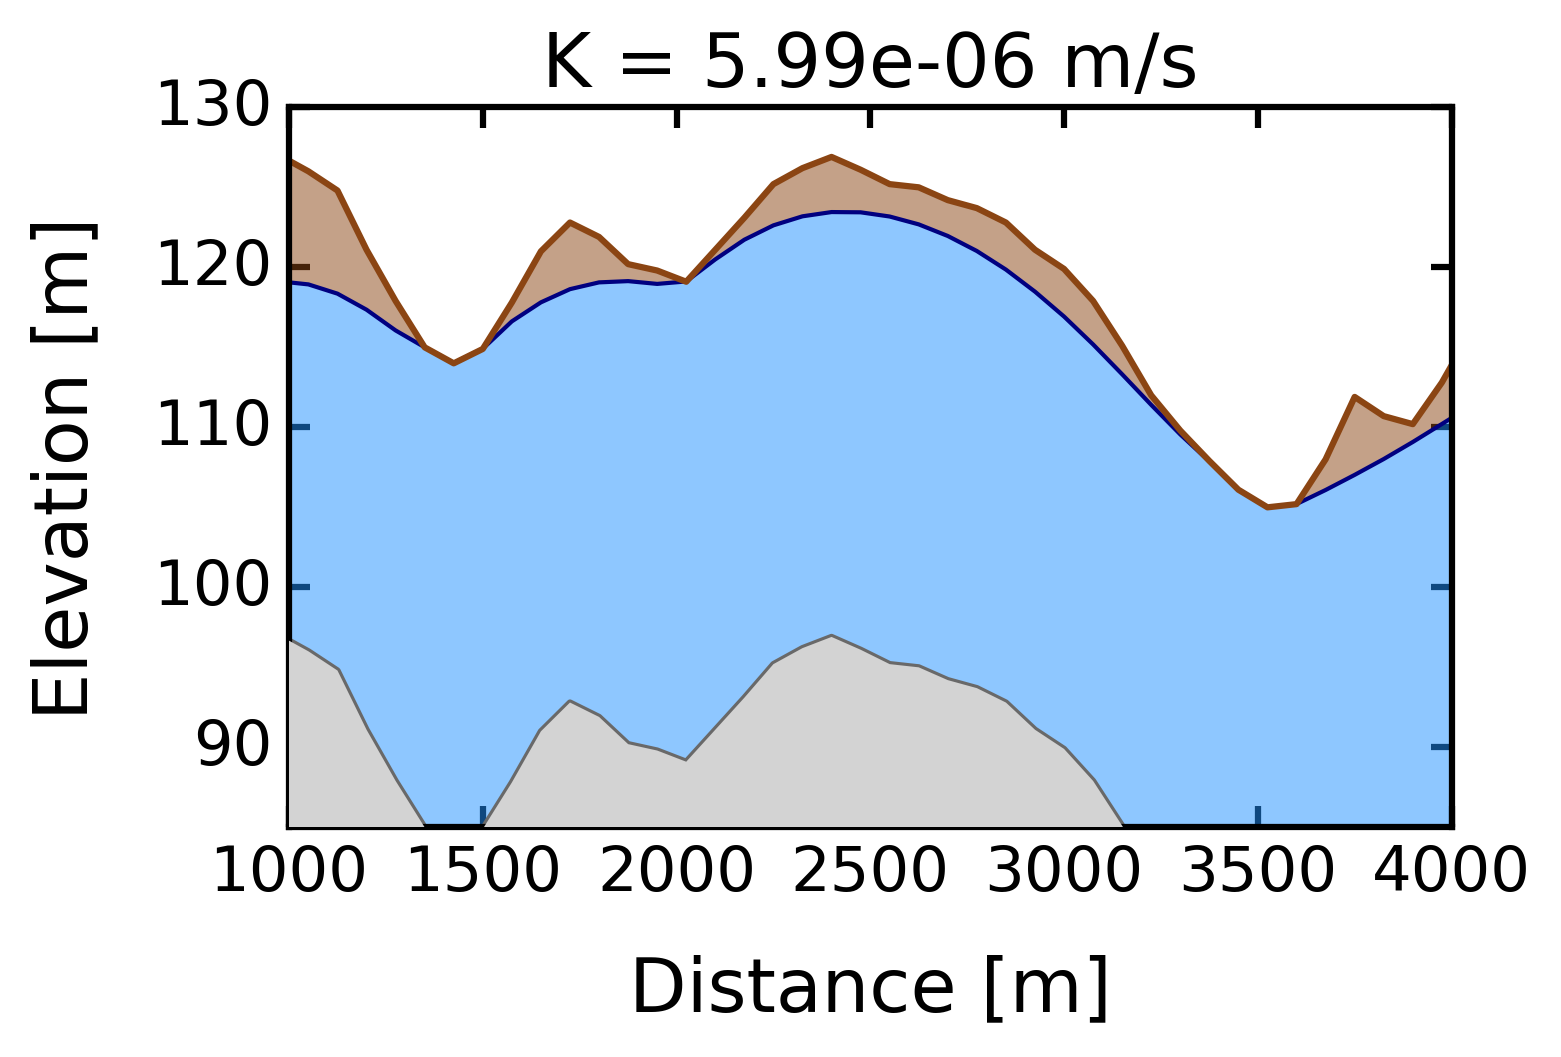

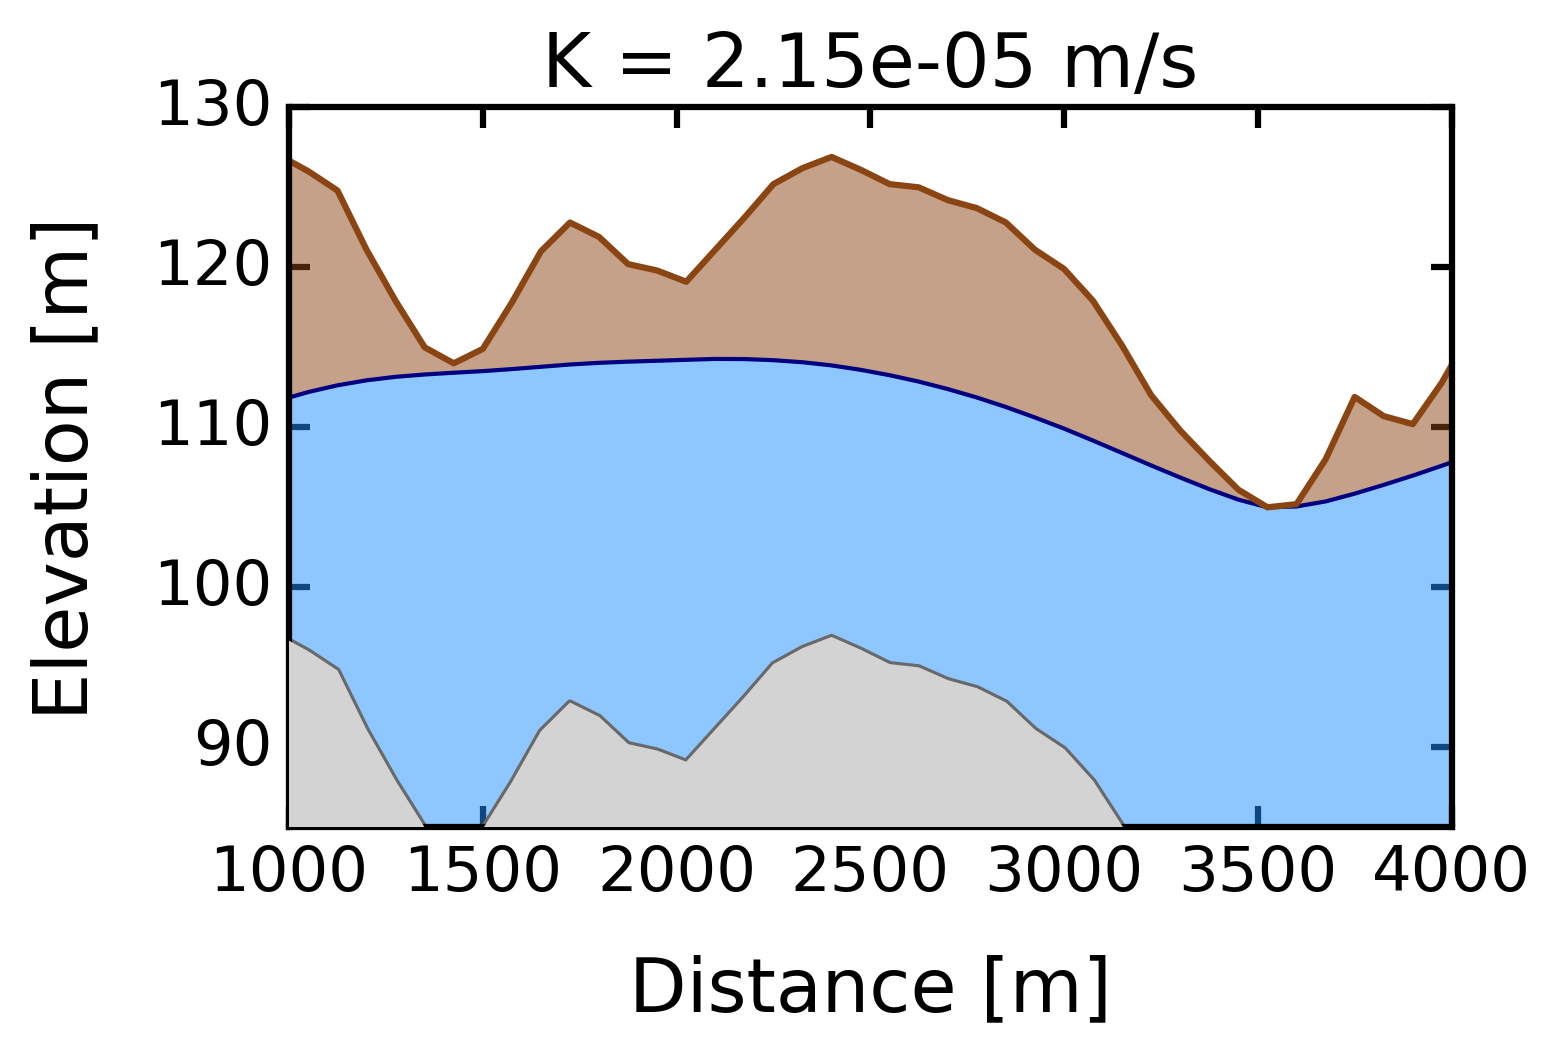

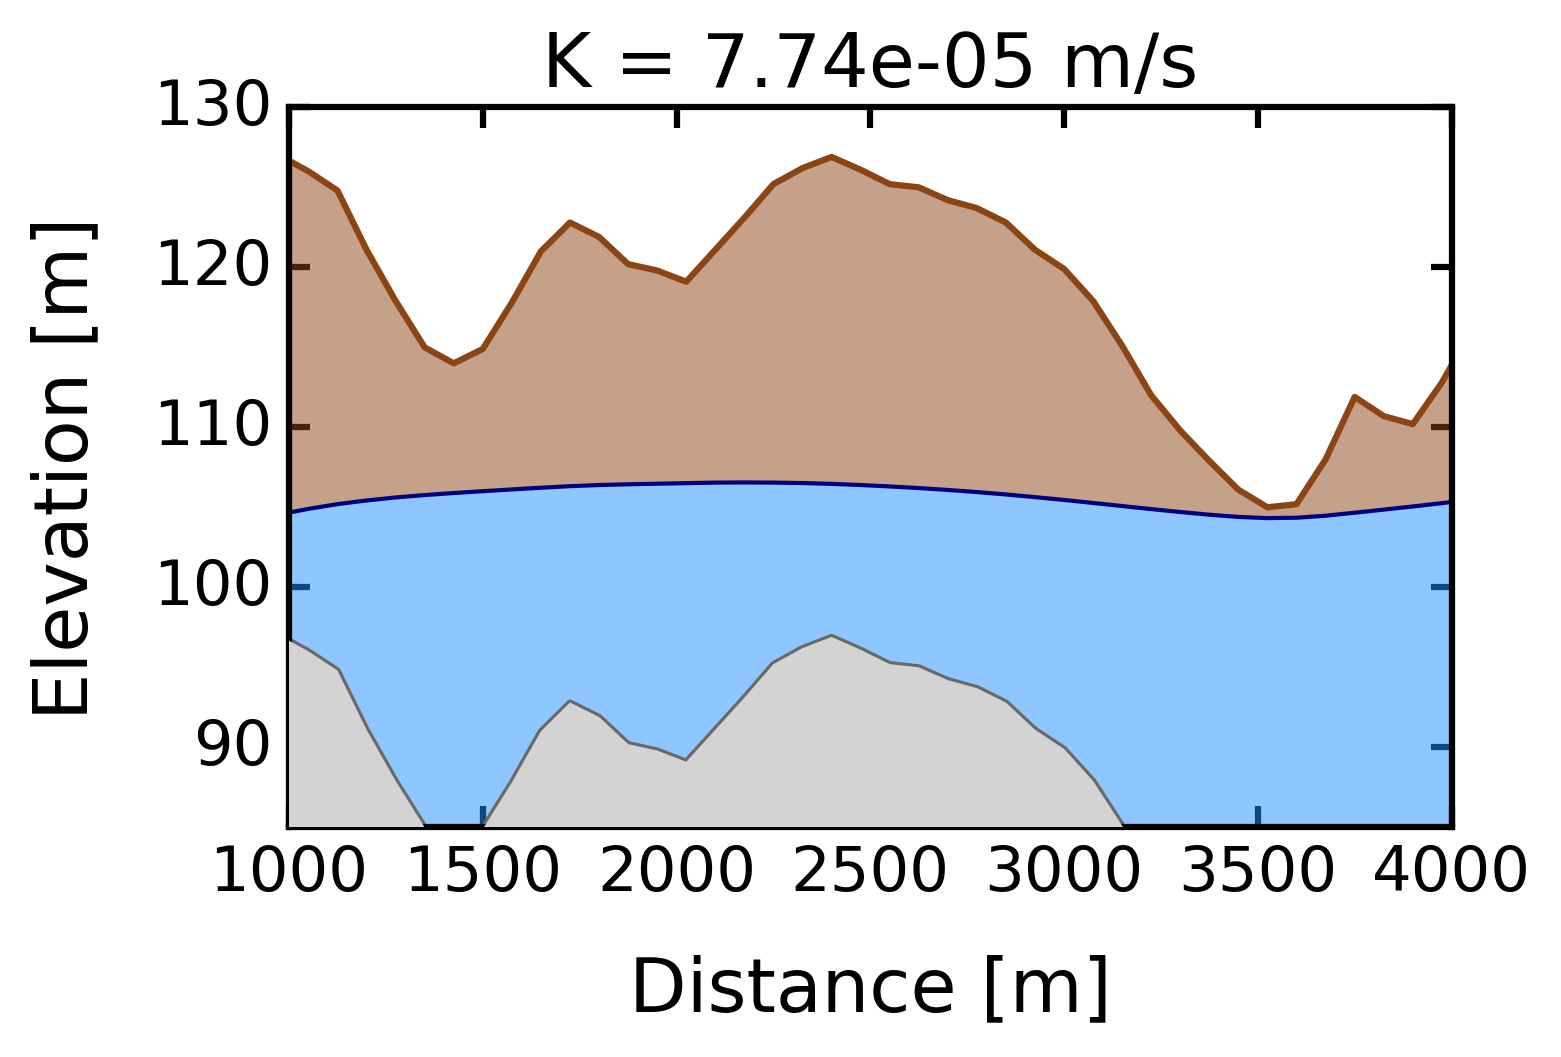

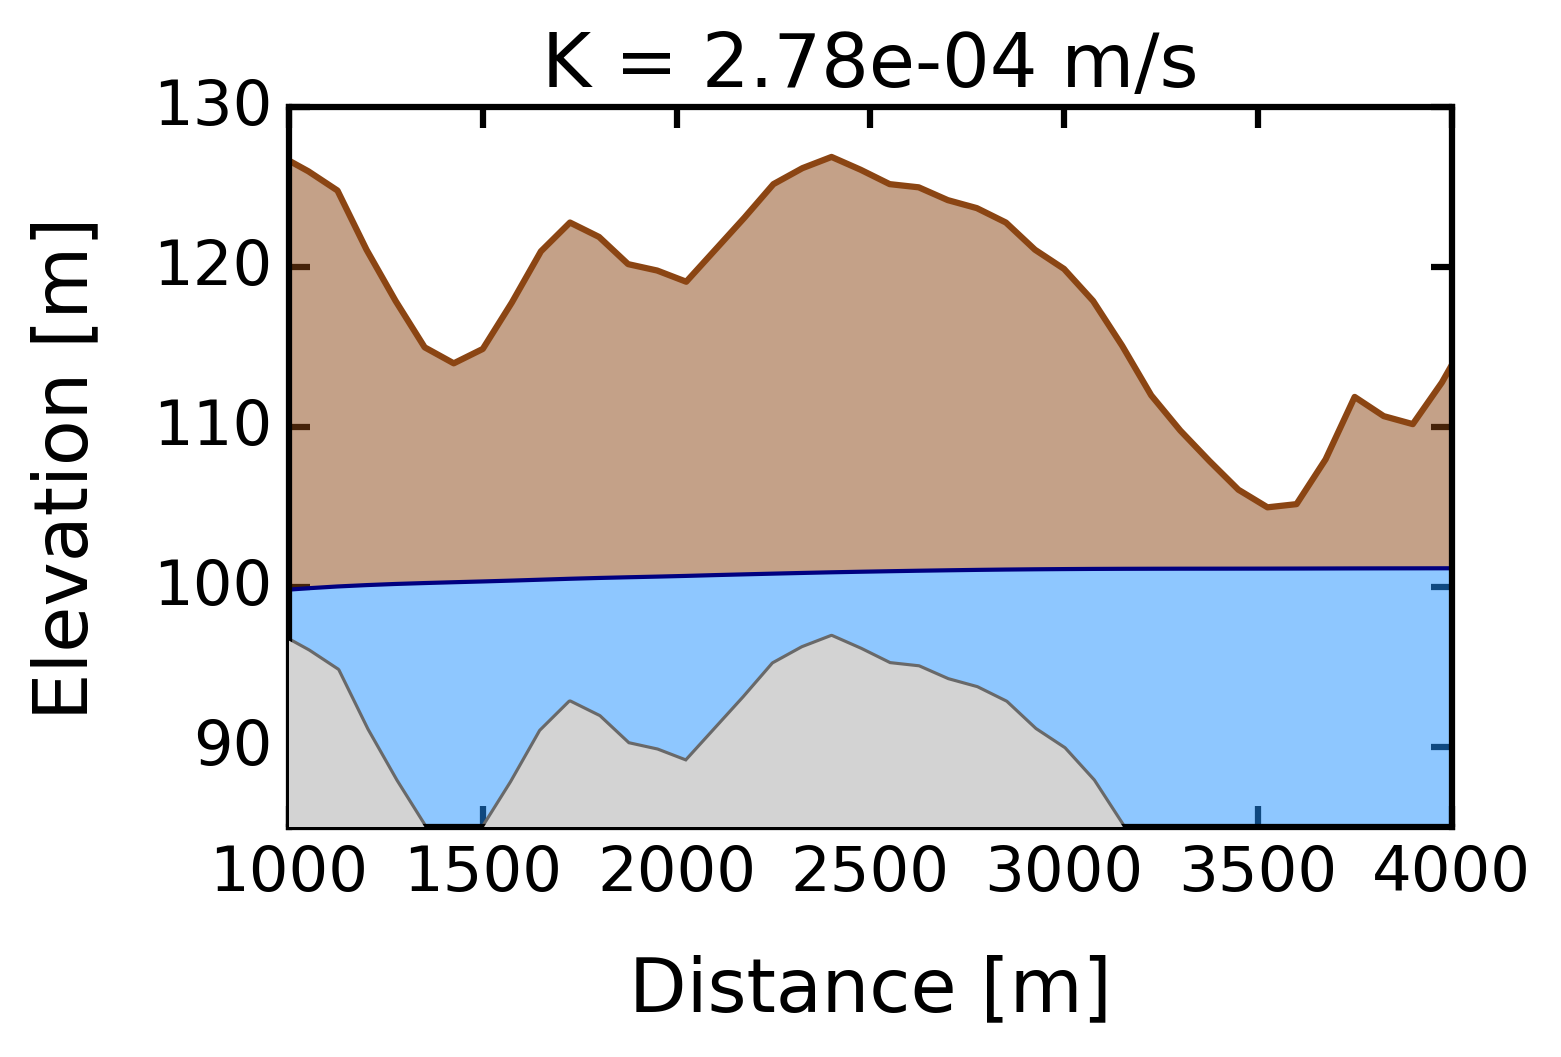

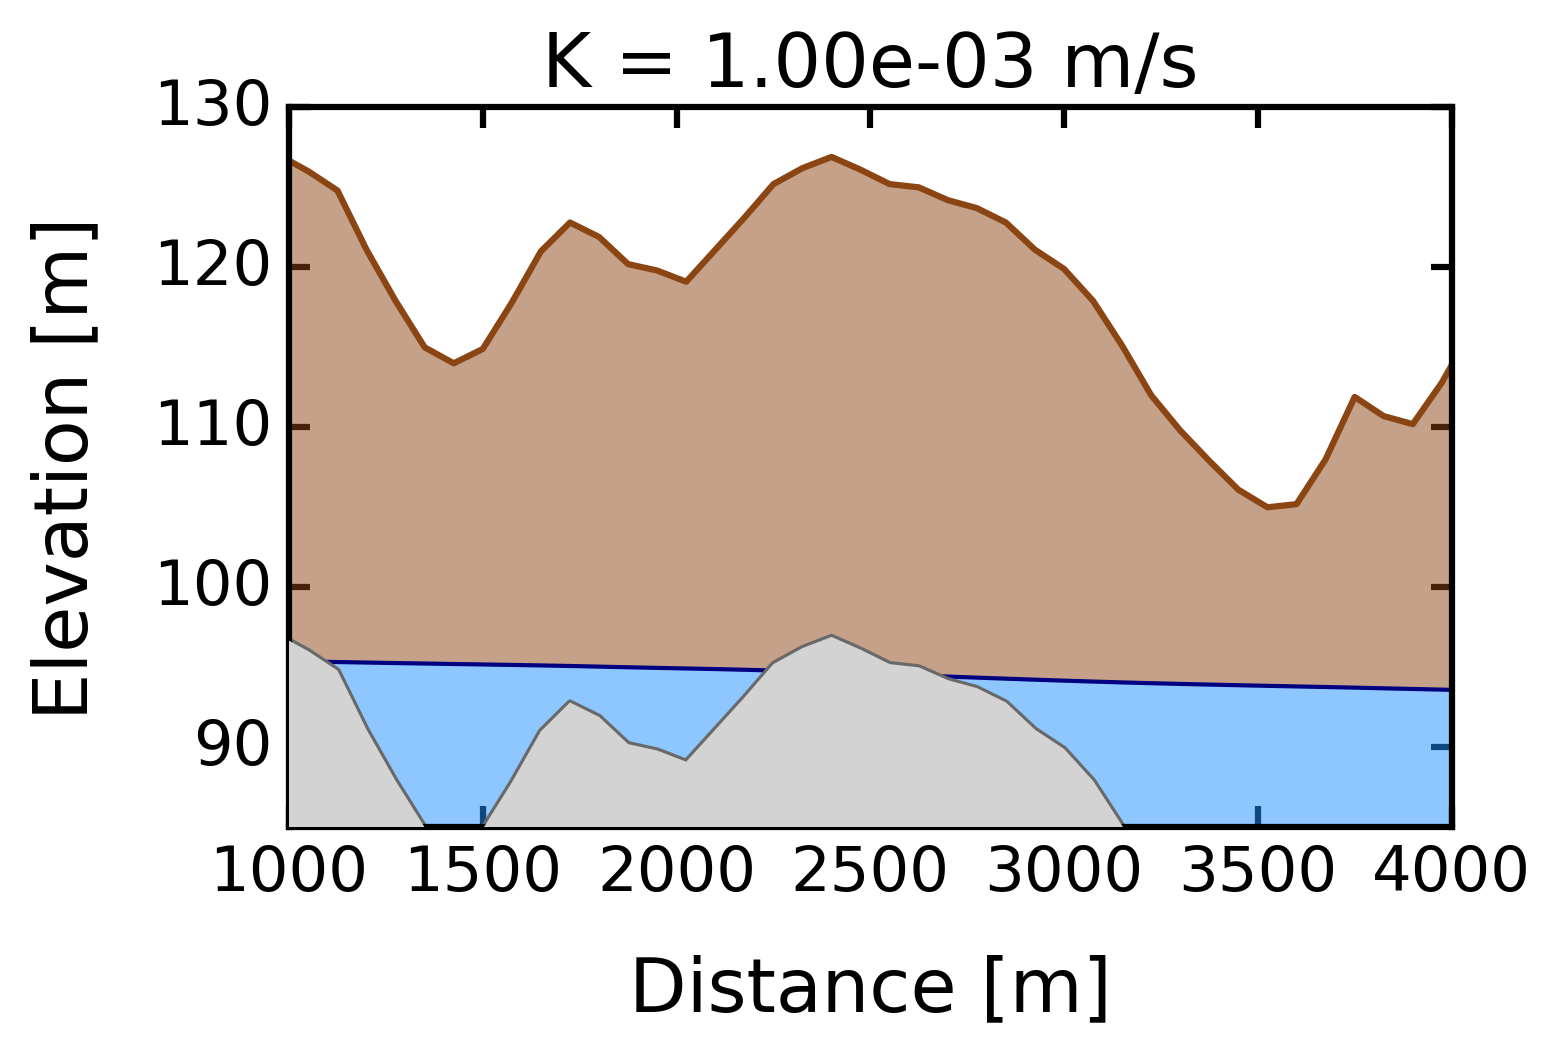

In [ ]:

compt = 1

for model_name, success_modflow, model_modflow in zip(list_model_name,
                                                      list_success_modflow,
                                                      list_model_modflow):

    fig, ax = plt.subplots(1, 1, figsize=(5,3), dpi=300)

    stable_folder = os.path.join(out_path, watershed_name, 'results_stable') # necessary for plots
    simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')

    dem_data = imageio.imread(BV.geographic.watershed_dem)
    dem_data = np.ma.masked_where(dem_data < 0, dem_data)

    wt_data = imageio.imread(os.path.join(simulations_folder, model_name,
                                          r'_postprocess/_rasters/watertable_elevation_t(0).tif'))
    wt_data = np.ma.masked_where(wt_data < 0, wt_data)

    river_data = imageio.imread(os.path.join(stable_folder, 'hydrography',
                                             'regional stream network.tif'))

    xvalues = np.linspace(-1,1,dem_data.shape[1])
    yvalues = np.linspace(-1,1,dem_data.shape[0])
    xx, yy = np.meshgrid(xvalues,yvalues)

    cur_x = dem_data.shape[1] /2
    # cur_y = dem_data.shape[0] /2

    dem_prof = dem_data.astype(float)
    dem_prof[dem_prof<0] = np.nan
    dem_v_plot = dem_prof[:,int(cur_x)]
    dem_v_plot[dem_v_plot == 0] = np.nan

    wt_prof = wt_data.astype(float)
    wt_prof[wt_prof<0] = np.nan
    wt_v_plot = wt_prof[:,int(cur_x)]
    wt_v_plot[wt_v_plot == 0] = np.nan

    # wt_prof_min = wt_data.astype(float)
    # wt_prof_min[wt_prof_min<0] = np.nan
    # wt_v_plot_min = wt_prof_min[:,int(cur_x)]
    # wt_v_plot_min[wt_v_plot_min == 0] = np.nan

    # Facecolor watertable
    wt_v_fill = ax.fill_between(np.arange(xx.shape[0])*75,
                                dem_v_plot-30, wt_v_plot,
                                color='dodgerblue', alpha=0.5, lw=0)
    # Line watertable
    w_prof = ax.plot(np.arange(xx.shape[0])*75, wt_v_plot, color='navy', lw=1)

    # Facecolor unsaturated
    wt_v_fill = ax.fill_between(np.arange(xx.shape[0])*75,
                                wt_v_plot, dem_v_plot,
                                color='saddlebrown', alpha=0.5, lw=0)

    # Line unsaturated
    d_prof = ax.plot(np.arange(xx.shape[0])*75, dem_v_plot, 'saddlebrown', lw=1.5)

    # Facecolor noflow
    ax.fill_between(np.arange(xx.shape[0])*75,
                    0, dem_v_plot-30,
                    color='lightgrey', alpha=1, lw=0, zorder=10)
    # Line noflow
    ax.plot(np.arange(xx.shape[0])*75, dem_v_plot-30, color='dimgray', lw=1.5)

    # Settings
    ax.set_xlim(1000, 4000)
    ax.set_ylim(85, 130)
    ax.set_yticks([90,100,110,120,130])
    ax.set_xlabel('Distance [m]')
    ax.set_ylabel('Elevation [m]')
    ax.set_title('K = '+'{:.2e}'.format(model_modflow.hk.mean()/24/3600)+' m/s')

    compt += 1

    fig.tight_layout

    # fig.savefig(os.path.join(model_modflow.figure_file,
    #             'CROSS_'+model_name+'_'+str(compt)+'.png'),
    #             bbox_inches='tight')

    # fig.savefig(os.path.join(model_modflow.save_fig,
    #             'CROSS_'+model_name+'_'+str(compt)+'.png'),
    #             bbox_inches='tight')



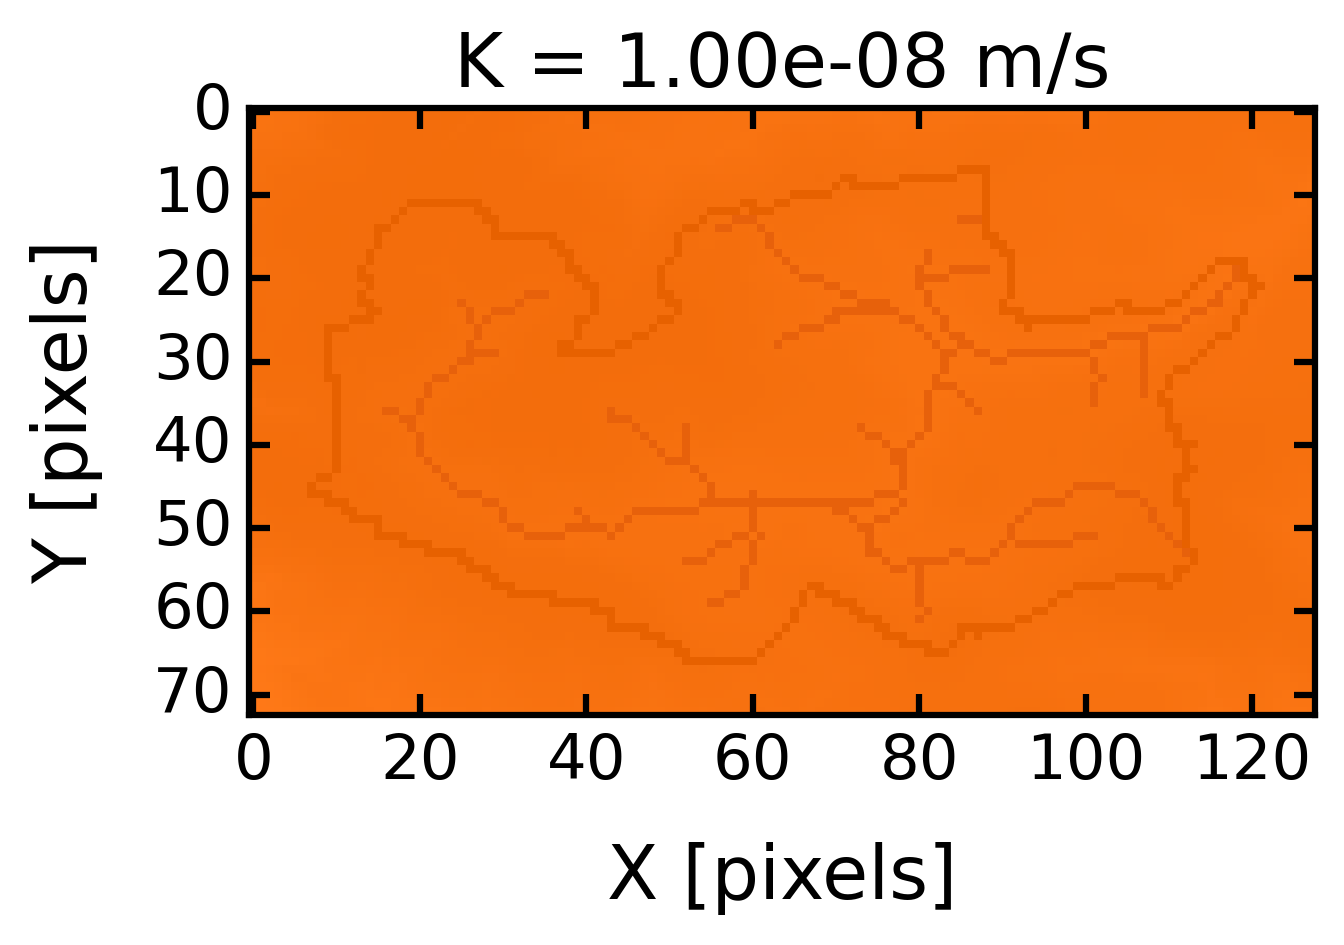

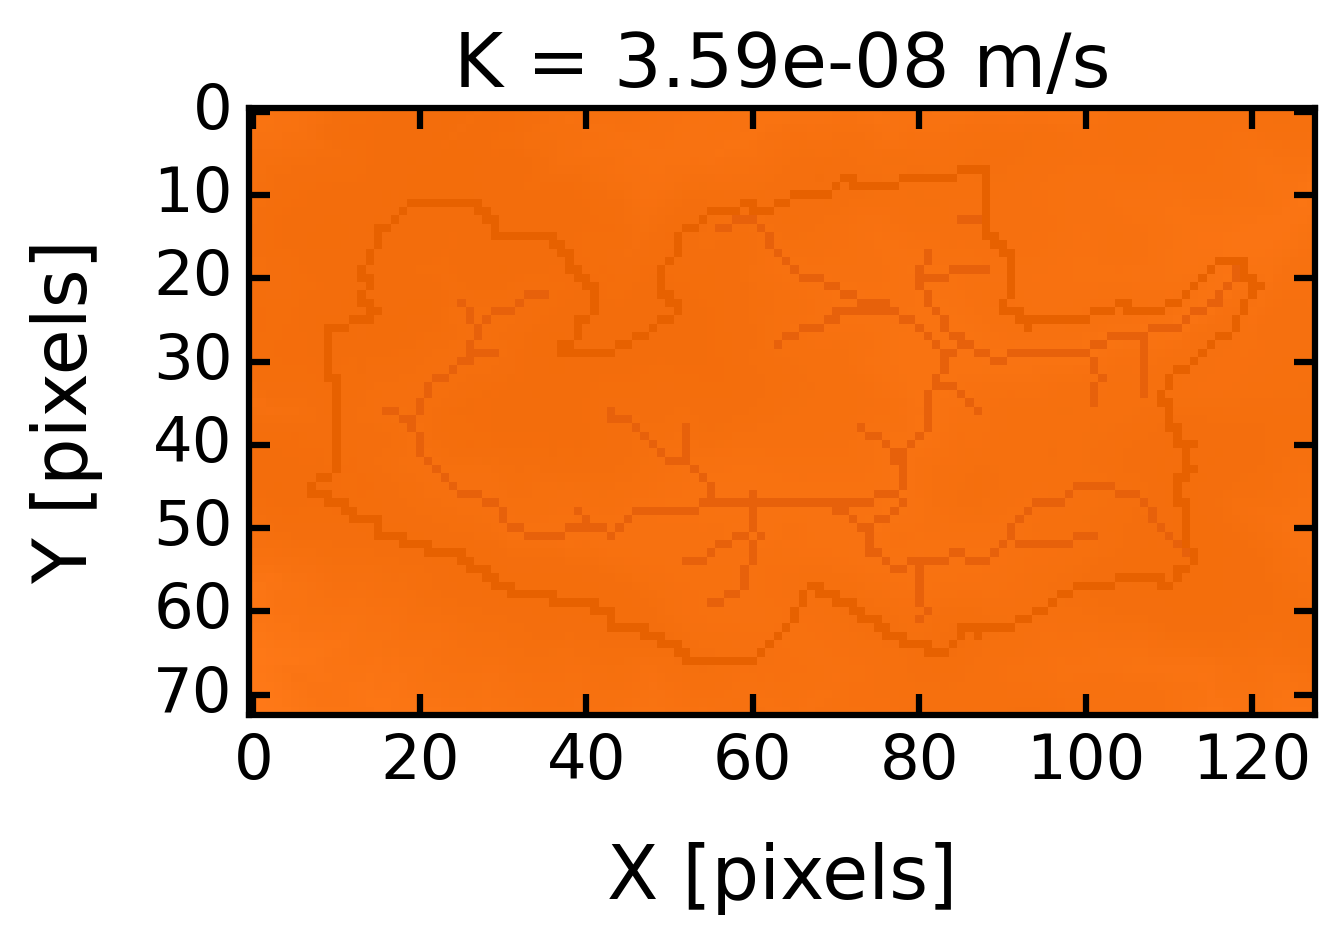

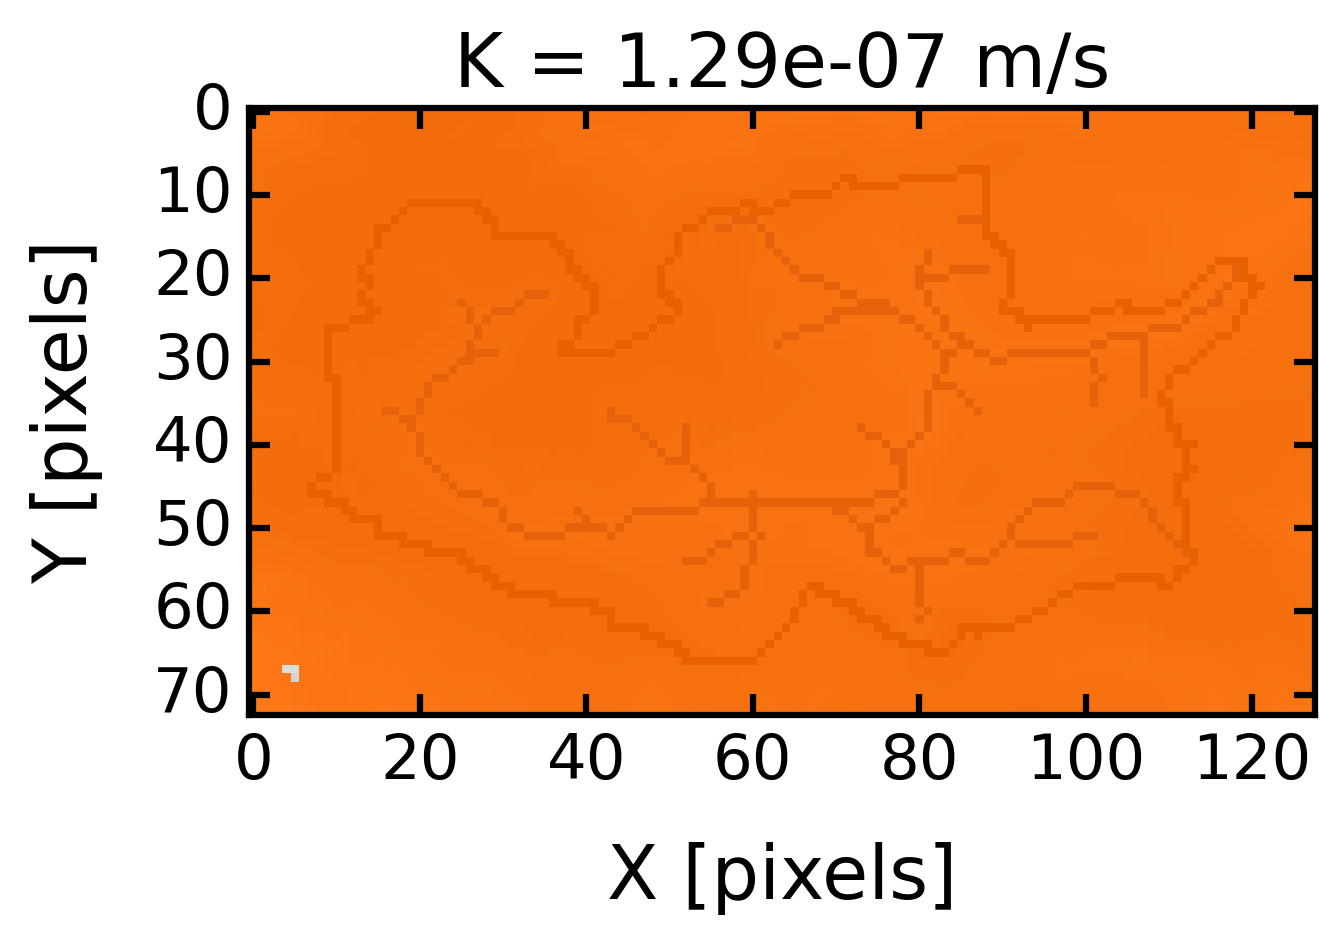

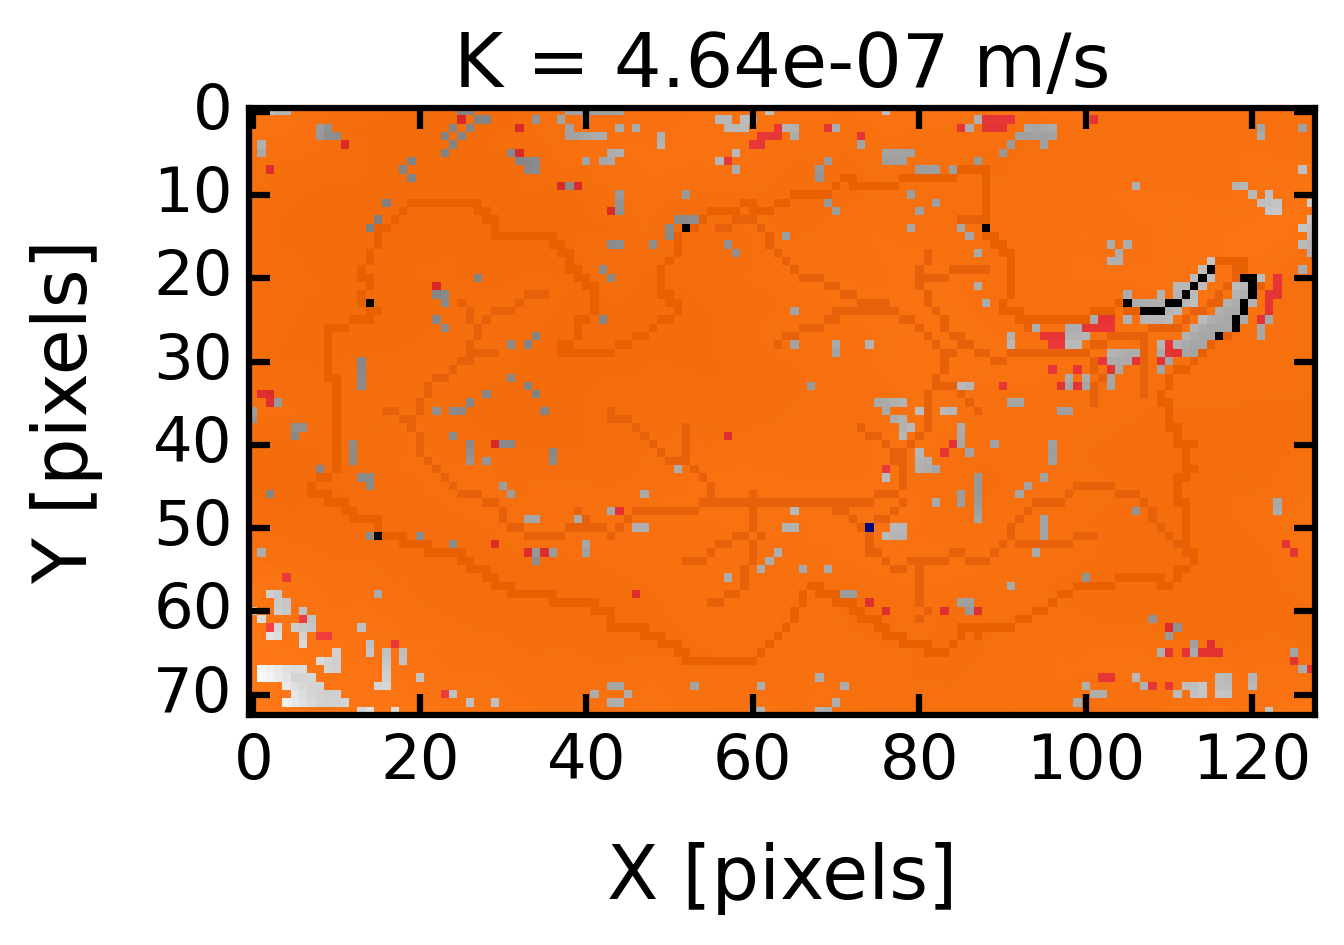

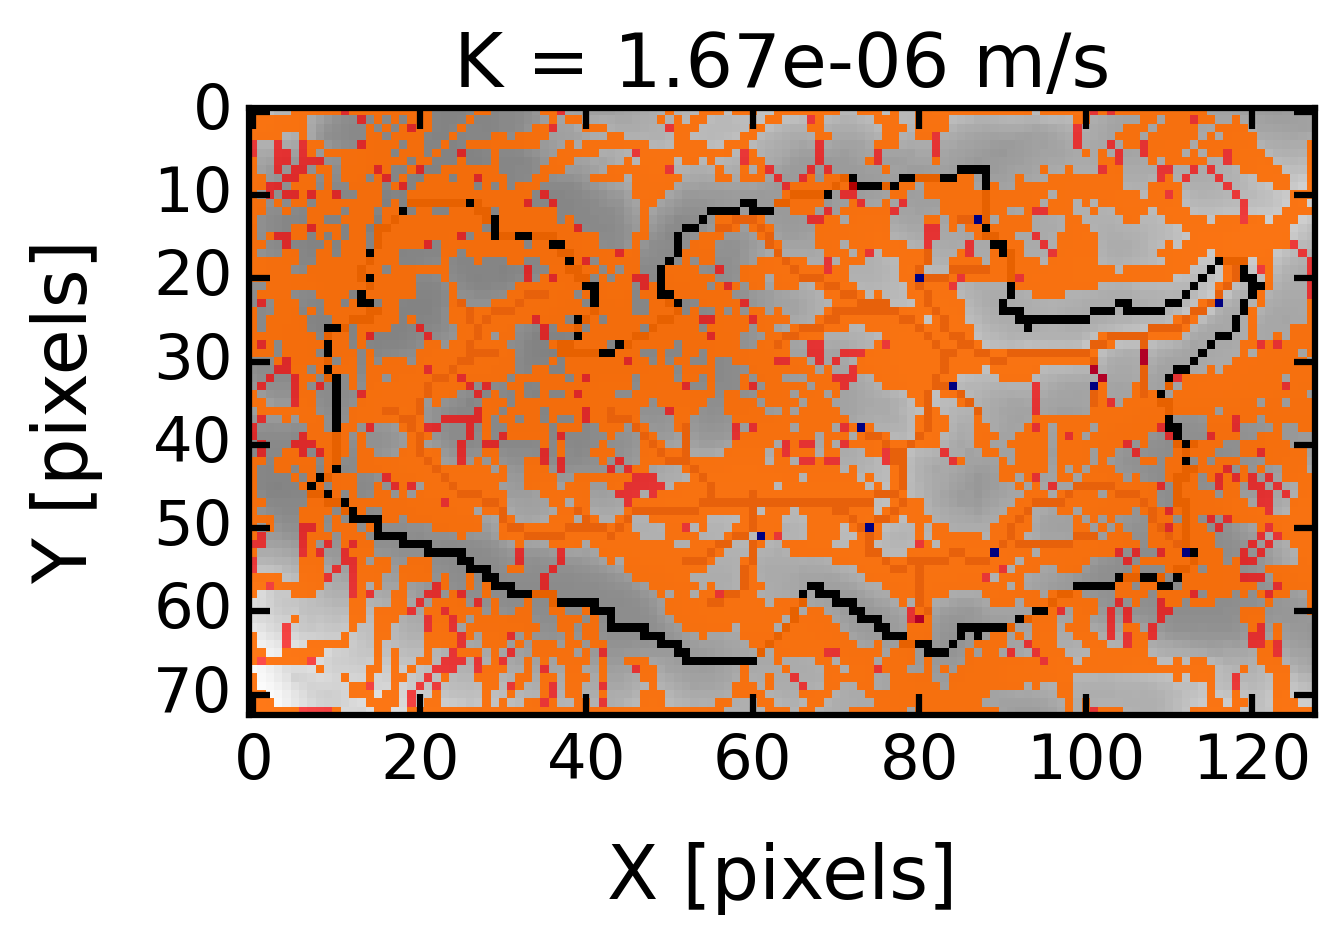

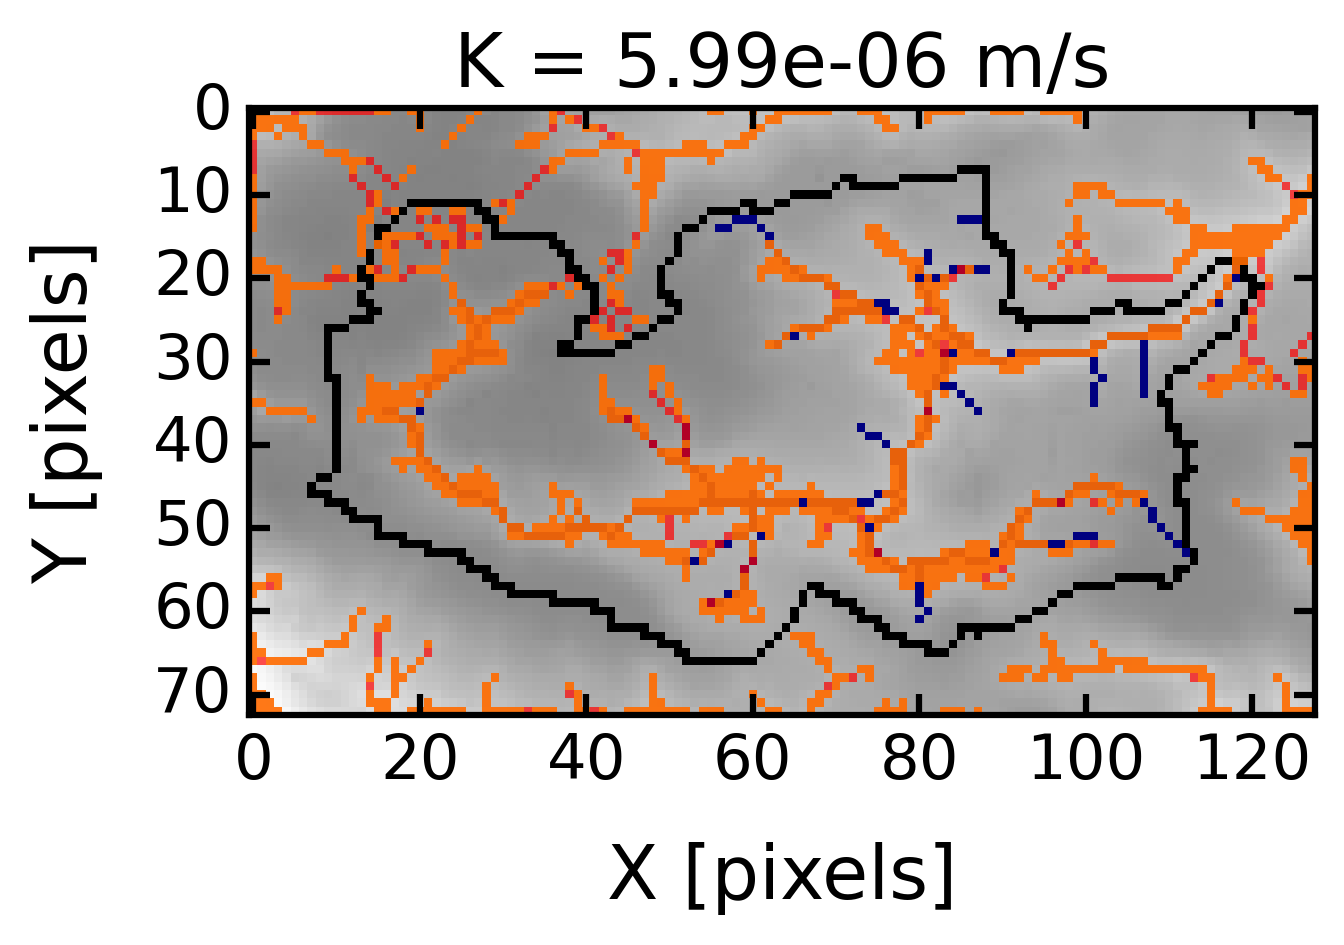

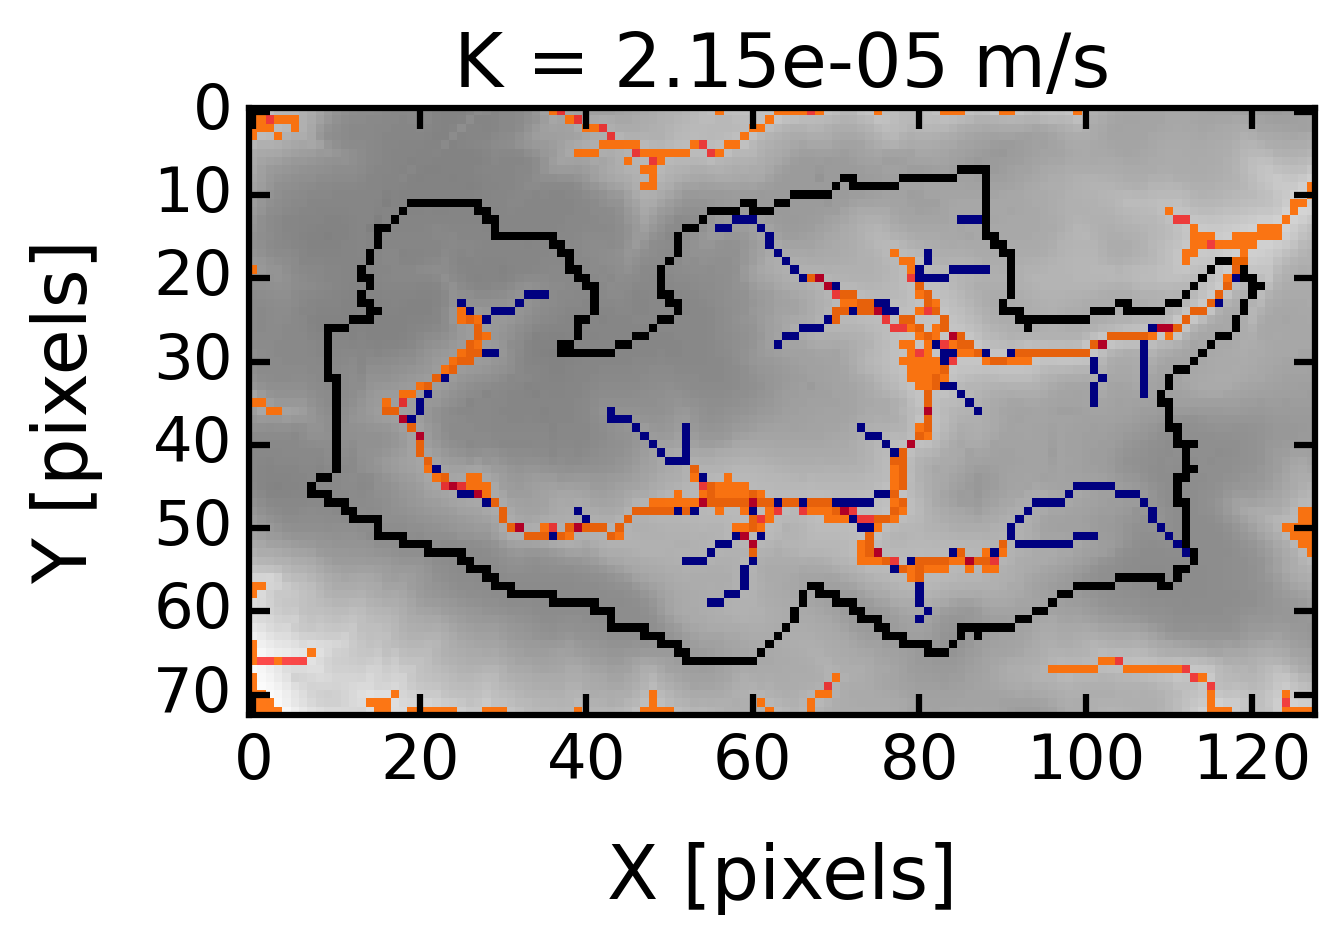

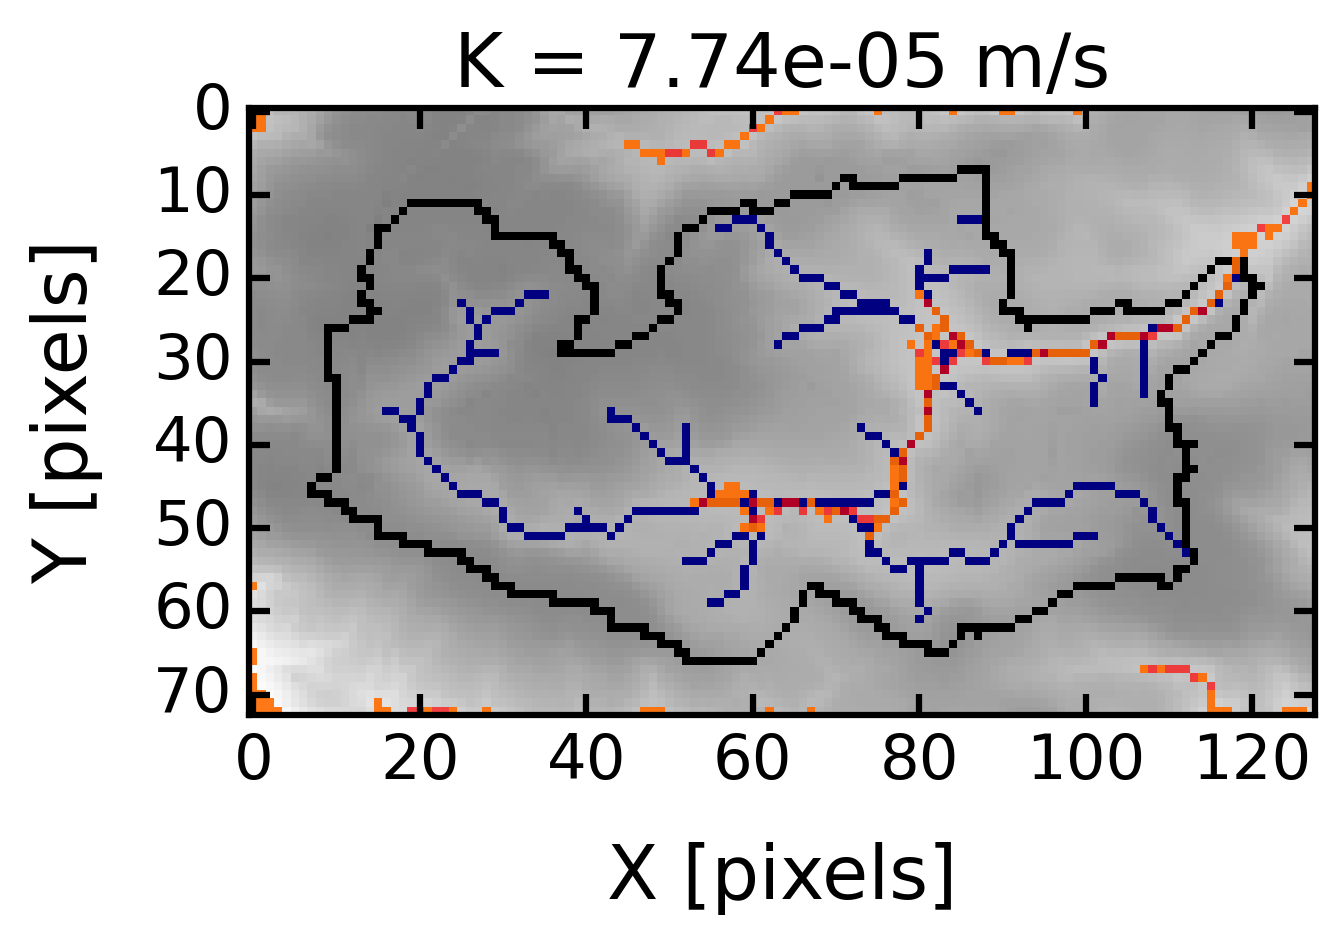

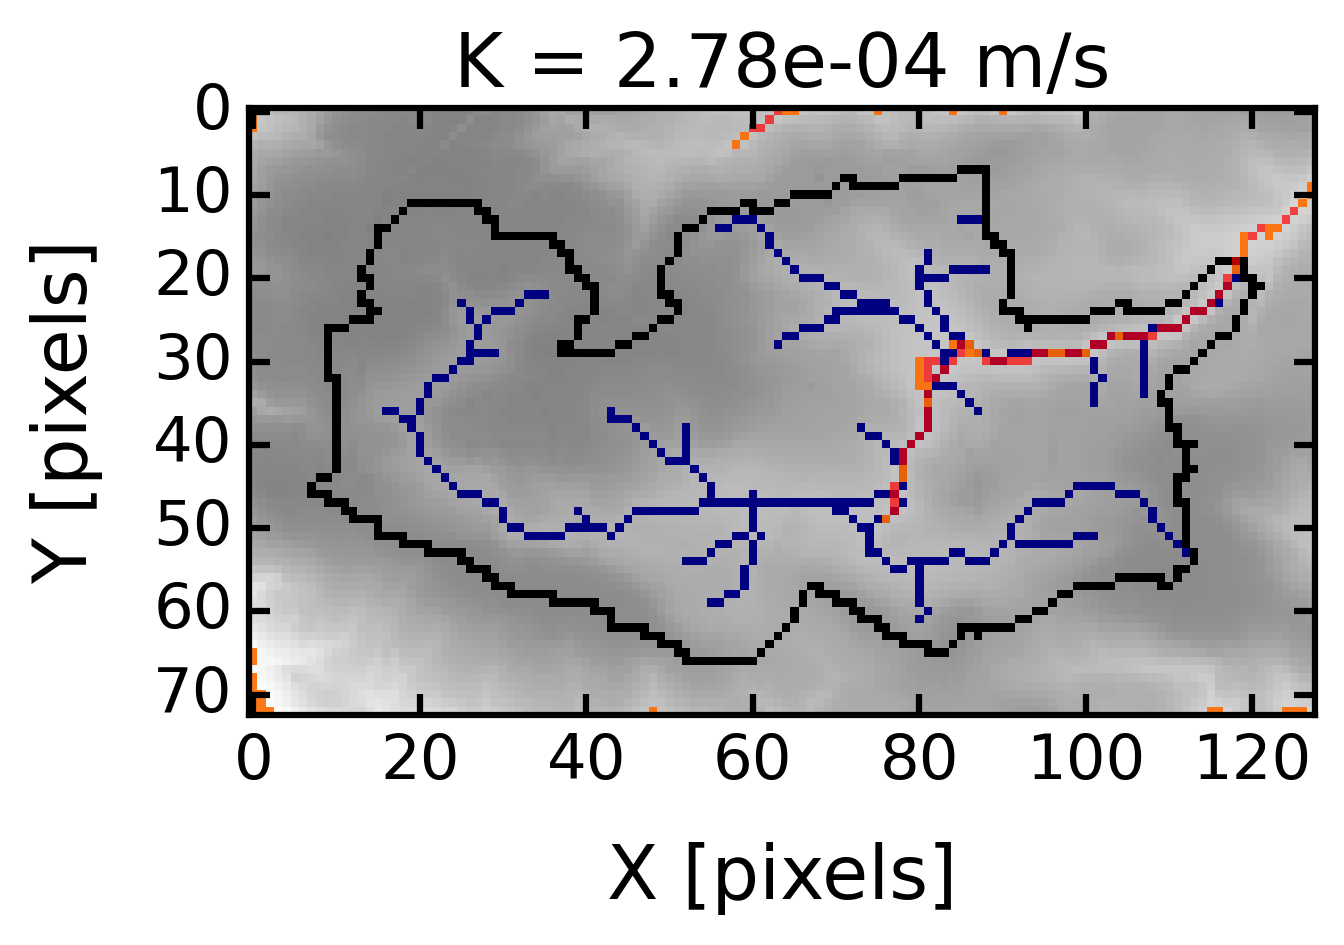

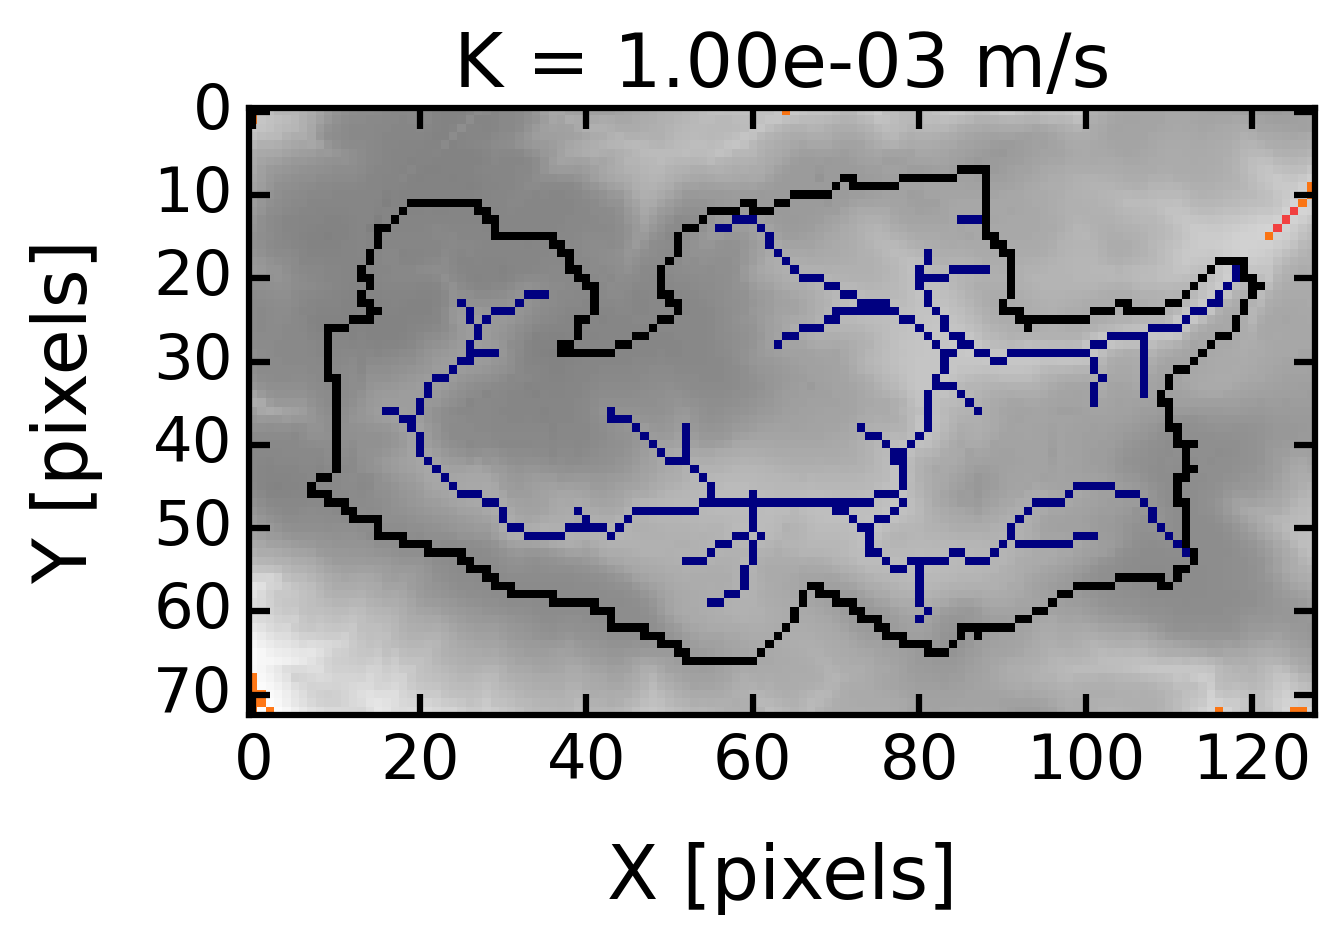

In [ ]:

compt = 0

for model_name, success_modflow, model_modflow in zip(list_model_name,
                                                      list_success_modflow,
                                                      list_model_modflow):

    fig, ax = plt.subplots(1, 1, figsize=(5,3), dpi=300)

    stable_folder = os.path.join(out_path, watershed_name, 'results_stable') # necessary for plots
    simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')

    dem_data = imageio.imread(BV.geographic.watershed_box_buff_dem)
    dem_data = np.ma.masked_where(dem_data < 0, dem_data)

    contour = imageio.imread(BV.geographic.watershed_contour_tif)
    contour = np.ma.masked_where(contour < 0, contour)

    obs_river_data = imageio.imread(os.path.join(stable_folder, 'hydrography',
                                                 'regional stream network.tif'))
    obs_river_data = np.ma.masked_where(obs_river_data < 0, obs_river_data)

    seep_river_data = imageio.imread(os.path.join(simulations_folder, model_name,
                                                  r'_postprocess/_rasters/seepage_areas_t(0).tif'))
    seep_river_data = np.ma.masked_where(seep_river_data <= 0, seep_river_data)

    sim_river_data = imageio.imread(os.path.join(simulations_folder, model_name,
                                                 r'_postprocess/_rasters/accumulation_flux_t(0).tif'))
    sim_river_data = np.ma.masked_where(sim_river_data <= 0, sim_river_data)

    im_dem = ax.imshow(dem_data, alpha=0.5, cmap='Greys')
    im_cont = ax.imshow(contour, alpha=1, cmap=mpl.colors.ListedColormap('k'))
    im_obs = ax.imshow(obs_river_data, alpha=1, cmap=mpl.colors.ListedColormap('navy'))
    im_sim = ax.imshow(sim_river_data, cmap=mpl.colors.ListedColormap('red'), alpha=0.7)
    im_seep = ax.imshow(seep_river_data, cmap=mpl.colors.ListedColormap('darkorange'), alpha=0.7)

    ax.set_xlabel('X [pixels]')
    ax.set_ylabel('Y [pixels]')
    ax.set_title('K = '+'{:.2e}'.format(model_modflow.hk.mean()/24/3600)+' m/s')

    compt += 1

    fig.tight_layout()

    # fig.savefig(os.path.join(model_modflow.figure_file,
    #             'MAP_'+model_name+'_'+str(compt)+'.png'),
    #             bbox_inches='tight')

    # fig.savefig(os.path.join(model_modflow.save_fig,
    #             'MAP_'+model_name+'_'+str(compt)+'.png'),
    #             bbox_inches='tight')



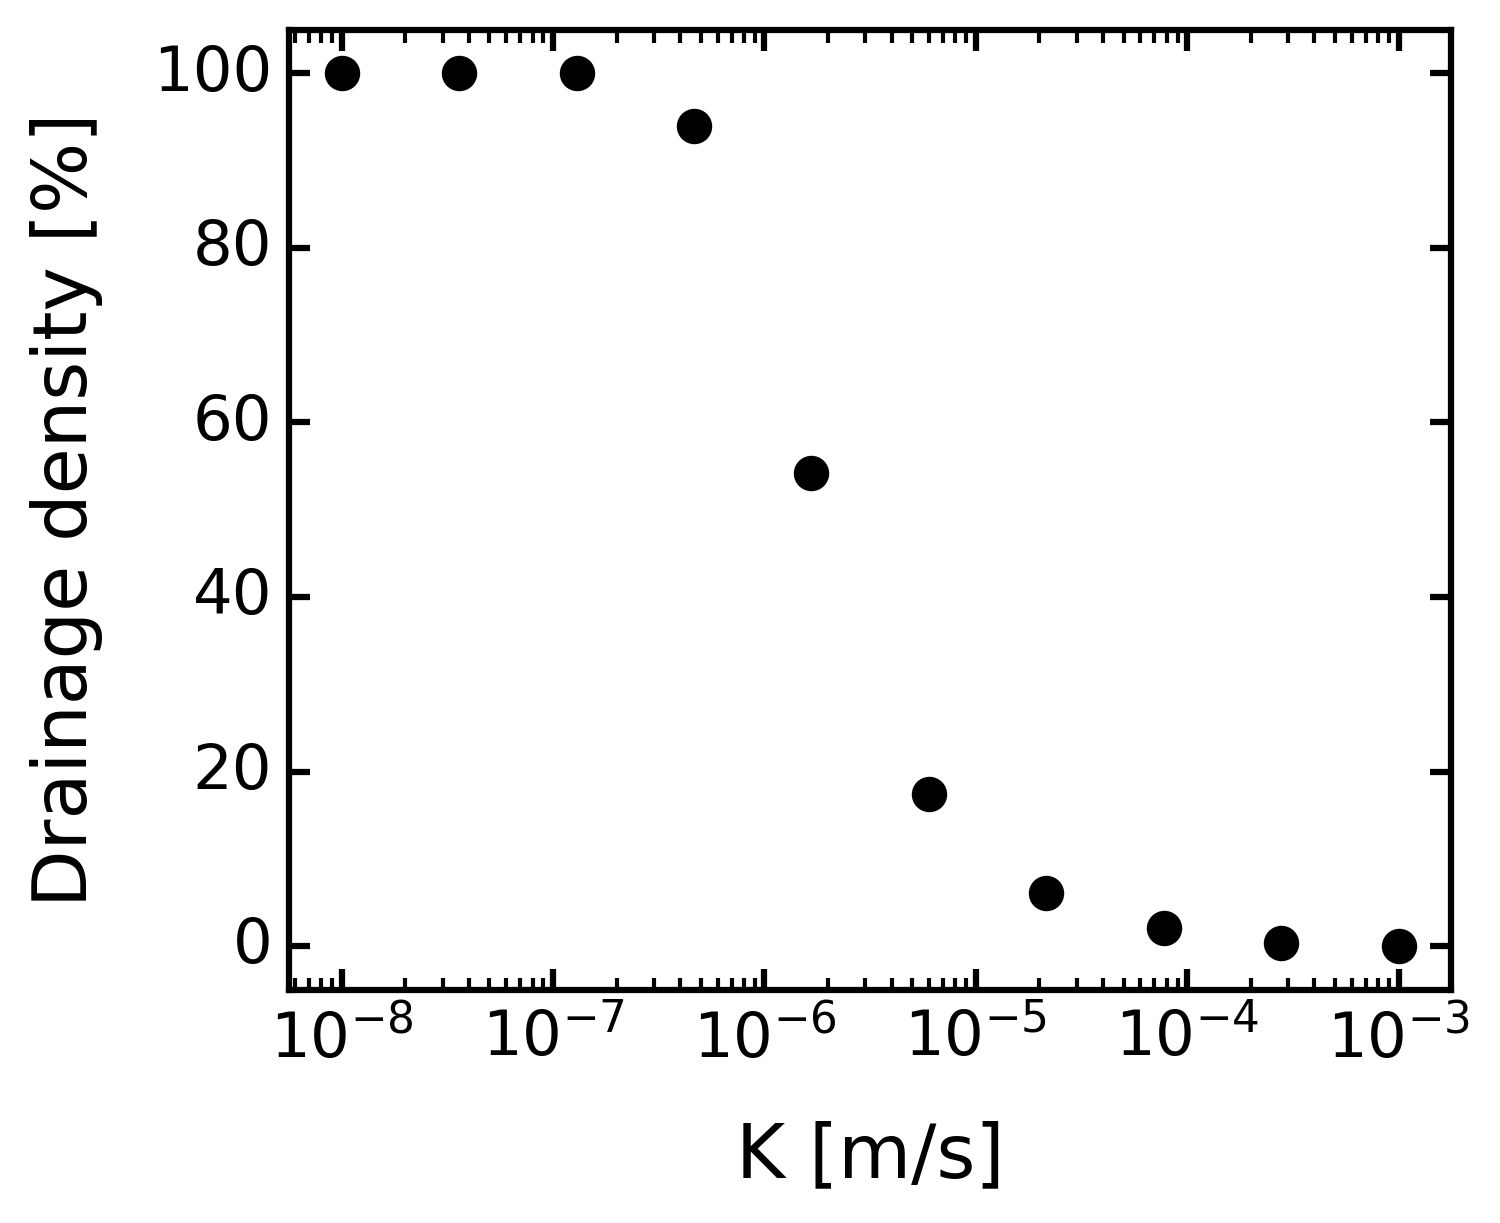

In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(5,4), dpi=300)

for model_name, success_modflow, model_modflow in zip(list_model_name,
                                                      list_success_modflow,
                                                      list_model_modflow):

    simulations_folder = os.path.join(out_path, watershed_name,
                                      'results_simulations')

    simul_csv = pd.read_csv(os.path.join(simulations_folder, model_name,
                            r'_postprocess/_timeseries/', '_simulated_timeseries.csv'),
                            sep=';')


    ax.plot(model_modflow.hk.mean()/24/3600,
            simul_csv['seepage_areas'],
            marker='o', ms=8, lw=0, color='k')

    ax.set_xscale('log')
    ax.set_xlabel('K [m/s]')
    ax.set_ylabel('Drainage density [%]')

    # fig.tight_layout()

    # fig.savefig(os.path.join(model_modflow.save_fig,
    #             'GRAPH_sat_'+iD_set_simulations+'.png'),
    #             bbox_inches='tight')



In [17]:

os.chdir(root_dir)
